# Predicting 30-day Hospital Readmission for Diabetic Patients
By: Jose Fernando A. Gonzales

---

## Notebook Purpose

This notebook covers the **Preprocessing, Exploratory Data Analysis (EDA), and Feature Engineering** phase of the ML lifecycle. Starting from the raw dataset explored in Notebook 01, we systematically prepare the data for modeling through:

1. **Data Cleaning** — Handle missing values (`?` markers), drop high-missing and constant-value columns, remove duplicates, and map categorical variables.
2. **Exploratory Data Analysis** — Visualize distributions, examine class imbalance in the target variable (`readmitted`), and analyze bivariate relationships across demographic, clinical, medication, and treatment features.
3. **Feature Engineering (10-Step Pipeline)** — Log-transform skewed features, one-hot encode categoricals, scale numerics, select features via Mutual Information, apply PCA for dimensionality reduction, and handle class imbalance with SMOTE.
4. **Summary & Artifact Export** — Save cleaned and fully preprocessed datasets, scaler, PCA transformer, and feature metadata for downstream modeling in Notebook 03.

**ML Lifecycle Stage:** Data Preparation → Feature Engineering

# Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")
print(f"✓ Random seed set to {RANDOM_STATE}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")

import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.preprocess import (
    check_missing_values,
    check_for_outliers,
    display_univariate_analysis,
    display_medication_eda,
    display_bivariate_analysis,
    display_correlation_analysis,
    filter_leakage_records,
    clean_gender
)

from src.feature_engineering import (
    add_utilization_features,
    recode_admission_type,
    group_discharge_disposition,
    group_admission_source,
    encode_clinical_flags,
    map_icd9_to_chapter
)


✓ All libraries imported successfully!
✓ Random seed set to 42
✓ NumPy version: 2.4.3
✓ Pandas version: 3.0.1


# Importing Dataset

In [2]:
filepath = "../data/raw/diabetic_data.csv"

df = pd.read_csv(filepath)
print(f"✓ Data loaded successfully from {filepath}")

display(df.head())

✓ Data loaded successfully from ../data/raw/diabetic_data.csv


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Data Preprocessing, EDA & Feature Engineering

## Data Cleaning

In [3]:
# Check for duplicates based on encounter_id
duplicate_count = df.duplicated(subset='encounter_id').sum()
print(f"✓ Number of duplicate entries based on encounter_id: {duplicate_count}")

✓ Number of duplicate entries based on encounter_id: 0


In [4]:
missing_summary = check_missing_values(df)
print("✓ Missing values summary:")
display(missing_summary)

✓ Columns with missing values represented as '?': ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
✓ Missing values summary:


,Missing Values,Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [5]:
# Replace NaN with 'none' in tests columns
test_columns = ['max_glu_serum', 'A1Cresult']
for col in test_columns:
    df[col] = df[col].fillna('none')
print(f"✓ Missing values in {test_columns} columns replaced with 'none'")

# Replace '?' with 'Unknown' in race column
df['race'] = df['race'].replace('?', 'Unknown')
print("✓ Missing values in 'race' column replaced with 'Unknown'")
display(df['race'].value_counts())

# Group less frequent medical specialties into 'Other' and replace '?' with 'Unknown'
df['medical_specialty'] = df['medical_specialty'].replace(df['medical_specialty'].value_counts()[df['medical_specialty'].value_counts() < 100].index, 'Other')
df['medical_specialty'] = df['medical_specialty'].replace('?', 'Unknown')
print("✓ Medical specialty counts after grouping:")
display(df['medical_specialty'].value_counts())

✓ Missing values in ['max_glu_serum', 'A1Cresult'] columns replaced with 'none'
✓ Missing values in 'race' column replaced with 'Unknown'


race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

✓ Medical specialty counts after grouping:


medical_specialty
Unknown                              49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Other                                  925
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Pediatrics                             254
Hematology/Oncology                 

In [6]:
# Check for fields with only one unique value (constant fields)
constant_fields = [col for col in df.columns if df[col].nunique() == 1]
print(f"✓ Constant fields (only one unique value): {constant_fields}")

# Identify columns to drop: identifiers, constant fields, and mostly missing fields
identifiers = ['encounter_id', 'patient_nbr']
mostly_missing = ['weight', 'payer_code']

to_drop = identifiers + constant_fields + mostly_missing
print(f"✓ Columns to drop: {to_drop}")

df_cleaned = df.drop(columns=to_drop)
print(f"✓ DataFrame shape after dropping columns: {df_cleaned.shape}")

✓ Constant fields (only one unique value): ['examide', 'citoglipton']
✓ Columns to drop: ['encounter_id', 'patient_nbr', 'examide', 'citoglipton', 'weight', 'payer_code']
✓ DataFrame shape after dropping columns: (101766, 44)


**Dropped columns.** Six columns were removed from the dataset prior to modeling:

- **encounter_id** and **patient_nbr** are row-level identifiers with no predictive value; retaining them would risk memorization rather than generalization.
- **weight** is missing for approximately 96.86% of records, far too sparse to impute reliably or contribute meaningful signal.
- **payer_code** is missing for roughly 39.56% of records and carries limited clinical relevance to 30-day readmission, making it more likely to introduce noise than predictive power.
- **examide** and **citoglipton** are constant columns (single unique value across all rows), providing zero variance and therefore no discriminative ability.

**Retained columns with missingness.** Four columns with notable missingness were kept after targeted treatment:

- **max_glu_serum** and **A1Cresult** had missing values replaced with the string `'none'`. In this clinical context, the absence of a lab test result is itself potentially informative — patients whose glucose or HbA1c was not measured may differ systematically from those who were tested, so encoding the missingness preserves that signal.
- **race** has low missingness (~2.23%) and was retained with missing entries recoded as `'Unknown'` to avoid discarding an otherwise complete and potentially important demographic feature, especially for downstream fairness analysis.
- **medical_specialty** is missing for approximately 49.08% of records — a substantial proportion. It was nonetheless retained because the admitting specialty may carry predictive signal for readmission risk. To manage its high cardinality, specialties with fewer than 100 occurrences were consolidated into an `'Other'` category, and missing entries were relabeled as `'Unknown'`.

In [7]:
# Correct the data types of id columns to 'category' since they are categorical in nature
df_cleaned['admission_type_id'] = df_cleaned['admission_type_id'].astype('category')
df_cleaned['discharge_disposition_id'] = df_cleaned['discharge_disposition_id'].astype('category')
df_cleaned['admission_source_id'] = df_cleaned['admission_source_id'].astype('category')
print("✓ Data types after correction:")
display(df_cleaned.dtypes)

✓ Data types after correction:


race                             str
gender                           str
age                              str
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
time_in_hospital               int64
medical_specialty                str
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                           str
diag_2                           str
diag_3                           str
number_diagnoses               int64
max_glu_serum                    str
A1Cresult                        str
metformin                        str
repaglinide                      str
nateglinide                      str
chlorpropamide                   str
glimepiride                      str
acetohexamide                    str
glipizide                        str
g

In [8]:
target = 'readmitted'
print(f"✓ Target variable identified: {target}")

numerical_columns = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
print(f"✓ Numerical columns identified: {list(numerical_columns)}")

categorical_columns = df_cleaned.select_dtypes(include=['object', 'category', 'str']).columns
categorical_columns = categorical_columns[categorical_columns != target]
print(f"✓ Categorical columns identified: {list(categorical_columns)}")

✓ Target variable identified: readmitted
✓ Numerical columns identified: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
✓ Categorical columns identified: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [9]:
outlier_summary = check_for_outliers(df_cleaned, numerical_columns)
print("✓ Outlier summary for numerical columns:")
display(outlier_summary)

print("✓ Summary statistics:")
display(df_cleaned.describe())

✓ Outlier summary for numerical columns:


,Column,Outlier Count,Outlier Percentage
0,time_in_hospital,2252,2.212920
1,num_lab_procedures,143,0.140518
2,num_procedures,4954,4.868031
3,num_medications,2557,2.512627
4,number_outpatient,16739,16.448519
5,number_emergency,11383,11.185465
6,number_inpatient,7049,6.926675
7,number_diagnoses,281,0.276124


✓ Summary statistics:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


The IQR method flagged outliers across all eight numerical columns, but the three prior-utilization variables stand out: `number_outpatient` (16.45% outliers), `number_emergency` (11.19%), and `number_inpatient` (6.93%). These counts are heavily zero-inflated — median values are 0 for all three — yet their maxima reach 42, 76, and 21 respectively, producing extreme right skew and wide IQR-based outlier fringes. Despite being statistical outliers, these values represent patients with genuinely high healthcare utilization and are clinically plausible rather than data-entry errors. In a readmission-prediction context, such patients are precisely the high-risk population the model should learn to identify; removing them would discard the very signal the task depends on.

The remaining columns show modest outlier rates: `num_procedures` (4.87%), `num_medications` (2.51%), `time_in_hospital` (2.21%), `number_diagnoses` (0.28%), and `num_lab_procedures` (0.14%). These proportions are within normal bounds for count-based clinical data and do not warrant removal.

No outlier capping or removal was applied. Tree-based models (Random Forest, XGBoost) are inherently robust to outliers and will naturally partition on these extreme values. For any linear model in the comparison, log or power transformations may be considered at the feature-engineering stage to compress the skewed tails without discarding observations.

In [10]:
filepath_cleaned = "../data/processed/diabetic_data_cleaned.csv"
df_cleaned.to_csv(filepath_cleaned, index=False)
print(f"✓ Cleaned DataFrame saved to {filepath_cleaned}")

✓ Cleaned DataFrame saved to ../data/processed/diabetic_data_cleaned.csv


## Exploratory Data Analysis (EDA)

### Univariate analysis of the target

✓ Univariate Analysis for Categorical Columns:


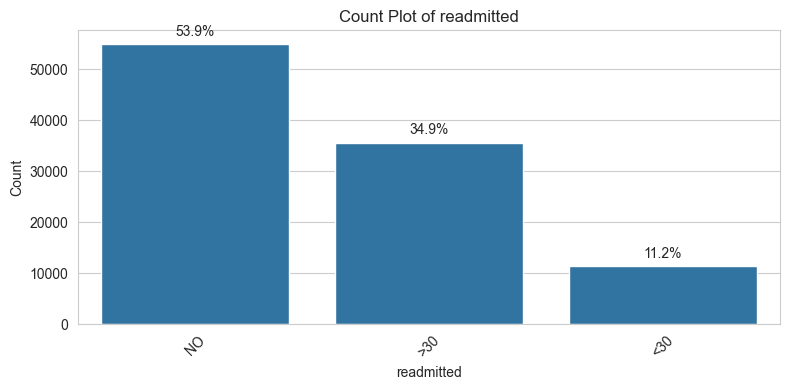

In [11]:
display_univariate_analysis(df_cleaned, None, [target])

For the interest of this project, we will convert readmitted into:

- 1 = readmitted within 30 days -> "<30"
- 0 = not readmitted within 30 days -> "NO" and ">30"

✓ Target variable 'readmitted' value counts after encoding:


readmitted
0    90409
1    11357
Name: count, dtype: int64

✓ Univariate Analysis for Categorical Columns:


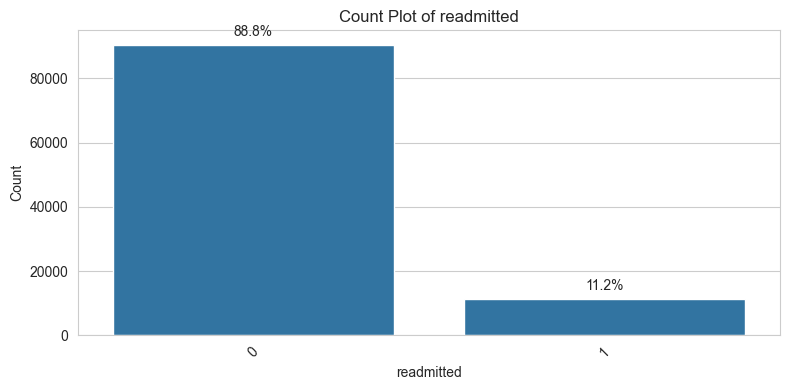

In [12]:
df_cleaned[target] = df_cleaned[target].replace({'<30': 1, '>30': 0, 'NO': 0})
print(f"✓ Target variable '{target}' value counts after encoding:")
display(df_cleaned[target].value_counts())

display_univariate_analysis(df_cleaned, None, [target])

After binarization, the target variable exhibits pronounced class imbalance: 90,409 encounters (88.8%) belong to the negative class (not readmitted within 30 days) while only 11,357 (11.2%) belong to the positive class, yielding an approximate 8:1 ratio. This level of imbalance is typical in hospital readmission datasets, where the majority of discharges do not result in a rapid return.

Left unaddressed, this imbalance will bias most classifiers toward predicting the majority class, inflating accuracy while suppressing recall on the positive class — the very outcome the project is designed to detect. Since the cost of missing a high-risk readmission is greater than the cost of a false positive, standard accuracy is a misleading metric here. AUC-ROC will serve as the primary evaluation metric, supplemented by recall, precision, and F1-score to assess the trade-off directly. At the modeling stage, techniques such as SMOTE, class-weight adjustment, or decision-threshold tuning will be applied to improve sensitivity to the minority class.

### Univariate analysis of the numerical columns

Given that we only have 8 numerical columns, we can do univariate analysis for all of them.

✓ Univariate Analysis for Numerical Columns:


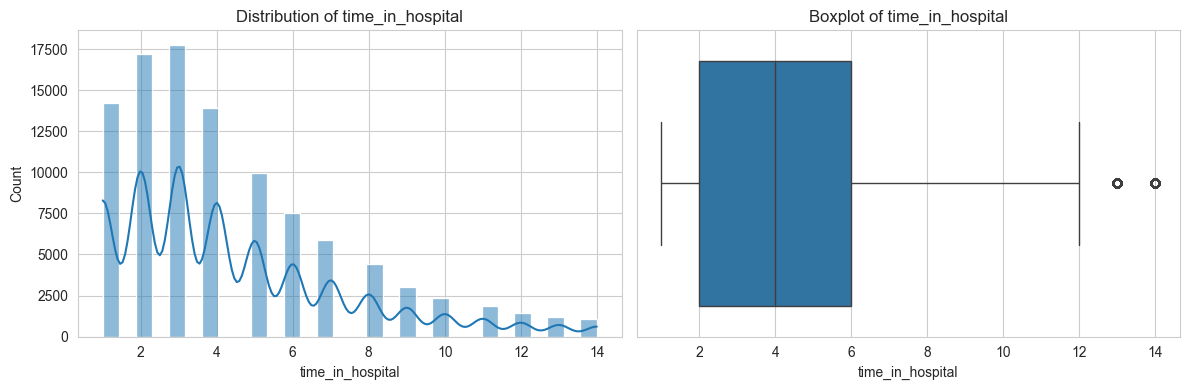

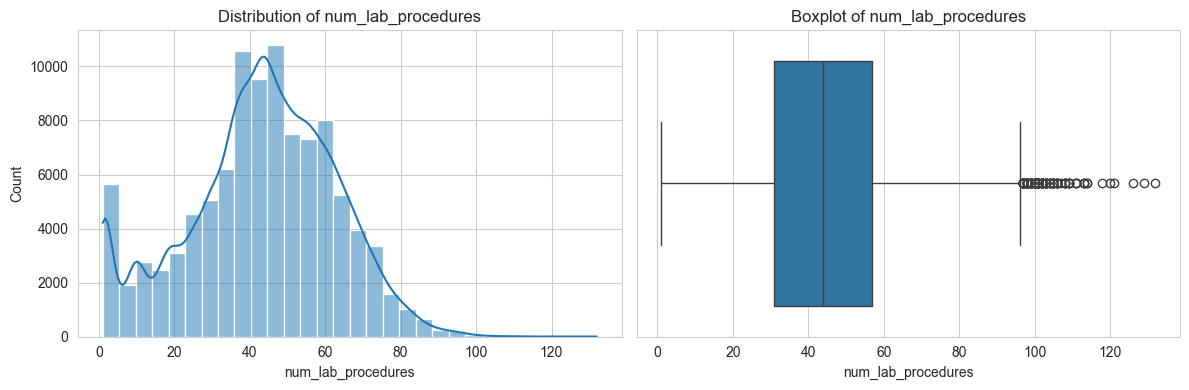

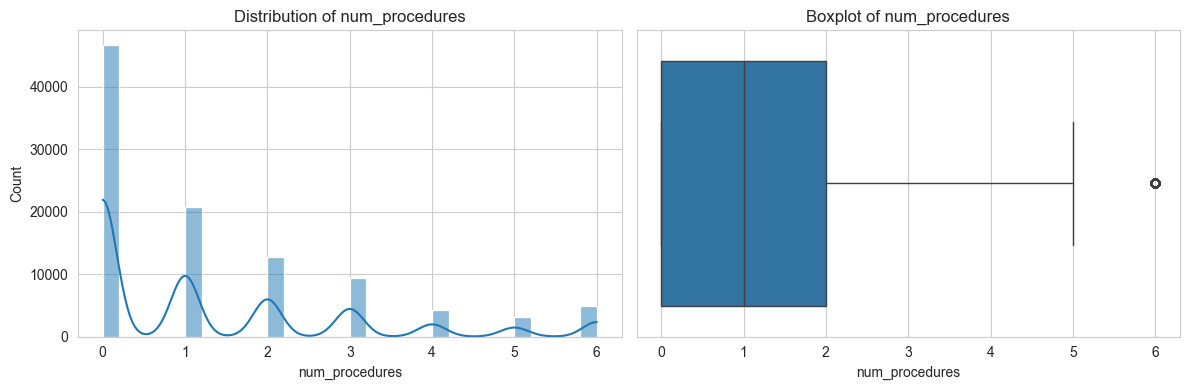

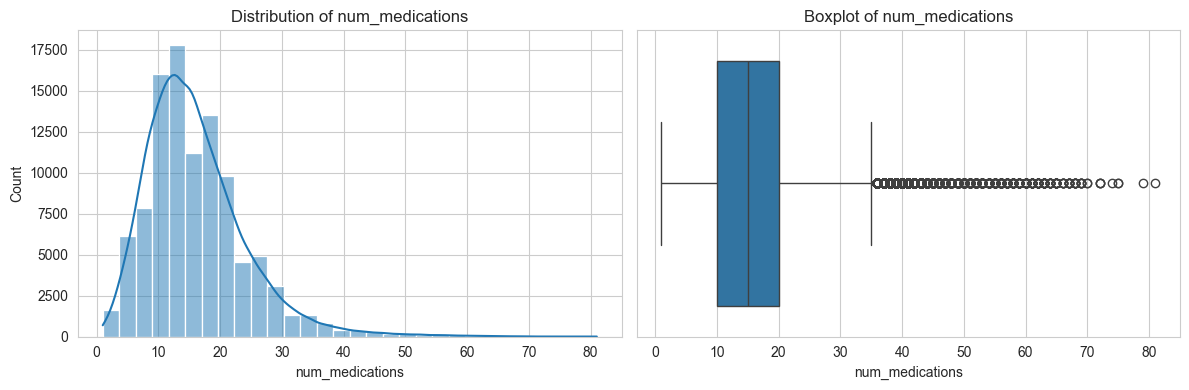

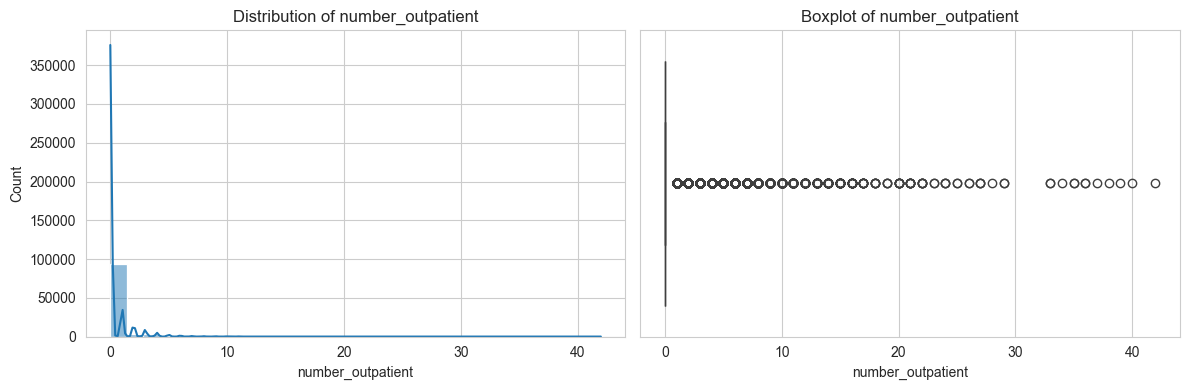

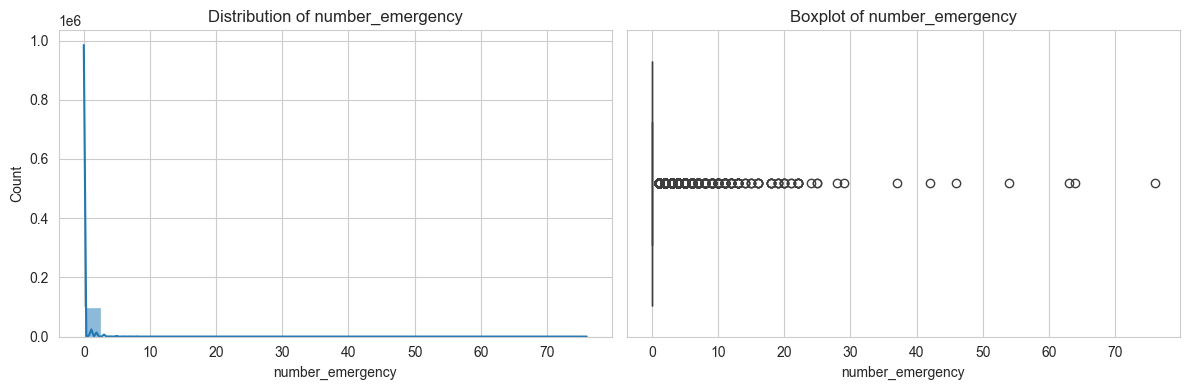

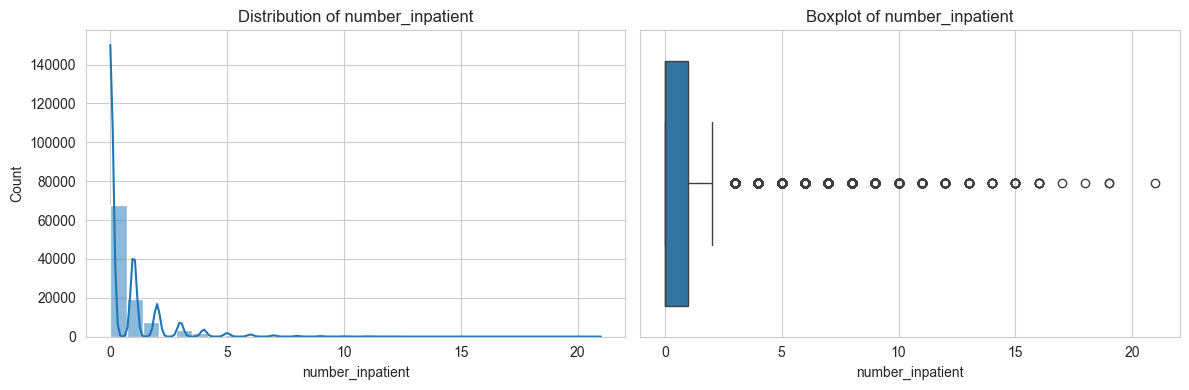

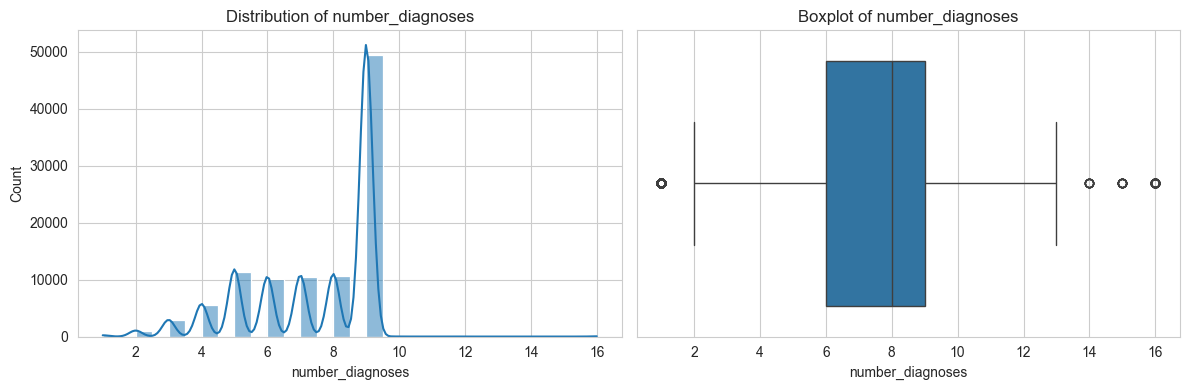

Summary statistics for numerical columns:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [13]:
display_univariate_analysis(df_cleaned, numerical_columns)

The eight numerical columns split naturally into two groups based on their distributional behaviour.

**Current-encounter clinical variables** — `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, and `number_diagnoses` — describe the intensity of the index admission itself. Of these, `num_lab_procedures` (mean 43.1, median 44) and `number_diagnoses` (mean 7.4, median 8, IQR 6–9) are the most symmetric and tightly bounded, suggesting relatively uniform measurement practices across encounters. `time_in_hospital` (mean 4.4 days, median 4, range 1–14) and `num_medications` (mean 16.0, median 15, max 81) are moderately right-skewed, with the extreme tail of `num_medications` likely reflecting patients on complex polypharmacy regimens — a clinically meaningful signal for readmission risk. `num_procedures` is similarly right-skewed with a median of 1 and a maximum of 6.

**Prior healthcare utilization variables** — `number_outpatient`, `number_emergency`, and `number_inpatient` — exhibit severe zero-inflation: the median (and both Q1 and Q2) are 0 for all three, yet their maxima reach 42, 76, and 21 respectively. This distributional shape is expected for event-count data in a general hospital population, where most patients have no recorded prior visits in the observation window. The small subset with high prior utilization are likely high-risk, chronically ill patients, making these variables potentially among the most predictive features despite — or because of — their extreme skew.

For tree-based models, these distributions present no preprocessing obstacle. For linear or distance-based models, log1p transformation of the skewed utilization counts (`number_outpatient`, `number_emergency`, `number_inpatient`, and possibly `num_medications`) should be evaluated to prevent the scale disparity from dominating gradient or distance calculations.

### Univariate analysis of the categorical columns

Given that there are 35 categorical columns, we will only analyze key columns. We will focus on demographics, clinical-related group, and treatment status group.

In [14]:
# Group categorical columns into meaningful categories for EDA and feature engineering

demographic_admin_group = [
    'race',
    'gender',
    'age',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'medical_specialty'
]

clinical_group = [
    'diag_1',
    'diag_2',
    'diag_3',
    'max_glu_serum',
    'A1Cresult'
]

treatment_status_group = [
    'change',
    'diabetesMed',
    'insulin'
]

medication_features_group = [
    col for col in categorical_columns
    if col not in demographic_admin_group + clinical_group + treatment_status_group
]

categorical_groups = {
    'demographic_admin': demographic_admin_group,
    'clinical': clinical_group,
    'treatment_status': treatment_status_group,
    'medication_features': medication_features_group
}

print("✓ Categorical columns grouped into:\n")
for group_name, cols in categorical_groups.items():
    print(f"{group_name} ({len(cols)} columns): {cols}")

✓ Categorical columns grouped into:

demographic_admin (7 columns): ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty']
clinical (5 columns): ['diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']
treatment_status (3 columns): ['change', 'diabetesMed', 'insulin']
medication_features (20 columns): ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


**Demographic Group**

✓ Univariate Analysis for Categorical Columns:


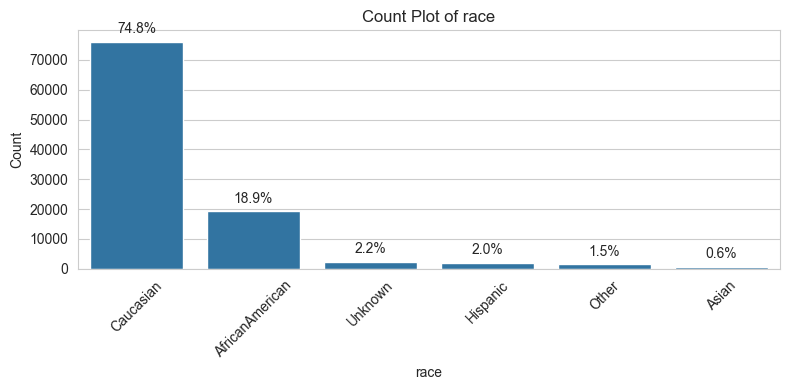

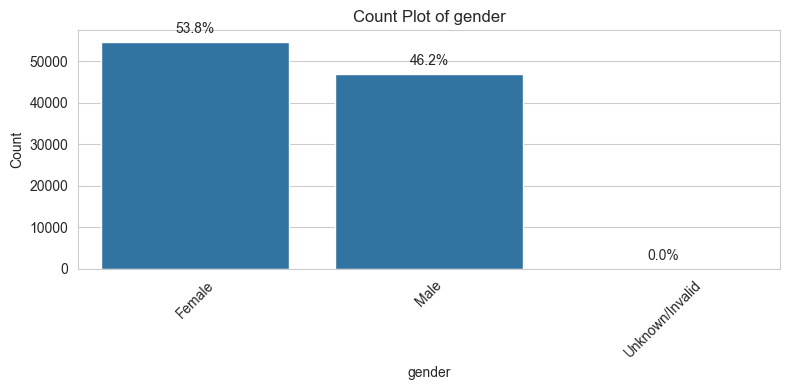

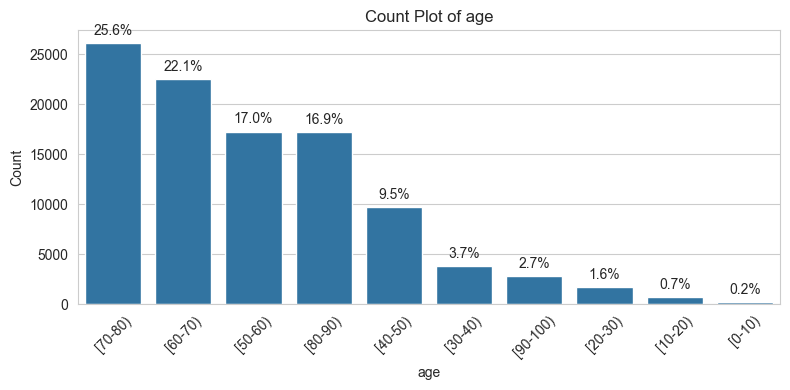

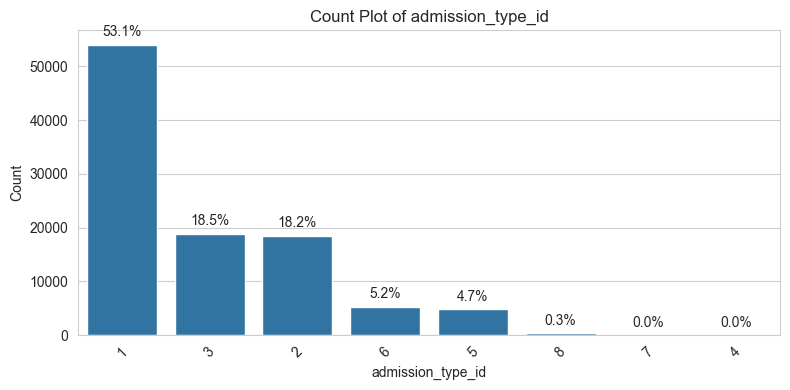

✓ Showing value counts for discharge_disposition_id (more than 10 unique values):


,count,percentage (%)
discharge_disposition_id,,
1,60234,59.2
3,13954,13.7
6,12902,12.7
18,3691,3.6
2,2128,2.1
22,1993,2.0
11,1642,1.6
5,1184,1.2
25,989,1.0


✓ Showing value counts for admission_source_id (more than 10 unique values):


,count,percentage (%)
admission_source_id,,
7,57494,56.5
1,29565,29.1
17,6781,6.7
4,3187,3.1
6,2264,2.2
2,1104,1.1
5,855,0.8
3,187,0.2
20,161,0.2


✓ Showing value counts for medical_specialty (more than 10 unique values):


,count,percentage (%)
medical_specialty,,
Unknown,49949,49.1
InternalMedicine,14635,14.4
Emergency/Trauma,7565,7.4
Family/GeneralPractice,7440,7.3
Cardiology,5352,5.3
Surgery-General,3099,3.0
Nephrology,1613,1.6
Orthopedics,1400,1.4
Orthopedics-Reconstructive,1233,1.2


In [15]:
display_univariate_analysis(df_cleaned, None, categorical_groups['demographic_admin'])

The demographic and administrative features collectively characterise the patient population across these 130 US hospitals and carry meaningful signals for both modeling and fairness evaluation.

**Race.** The dataset is heavily Caucasian-dominated (74.8%), with African American patients forming the next-largest group (18.9%). Hispanic (2.0%), Other (1.5%), and Asian (0.6%) patients combined account for fewer than 5% of encounters. This concentration warrants deliberate attention during fairness analysis: models trained on this distribution risk poor generalisation to underrepresented groups, and differential performance across racial subgroups should be explicitly assessed in the evaluation stage.

**Gender.** The split is moderately skewed toward female patients (53.8% vs 46.2% male). Three records classified as `Unknown/Invalid` are negligible and can be dropped without meaningful data loss.

**Age.** The population skews strongly toward older adults. The [70–80) cohort is the largest (25.6%), followed by [60–70) (22.1%) and [80–90) (16.9%); patients aged 60 and above account for approximately 67% of all encounters. Patients under 40 represent fewer than 6%. This distribution is clinically consistent with the higher prevalence of Type 2 diabetes and comorbidities in older populations. For feature engineering, collapsing the ten bins into broader ordinal bands (e.g., <50, 50–69, 70+) may reduce noise while preserving the clinically meaningful risk gradient. As age is encoded as an ordinal string interval, it will require ordinal encoding or numeric midpoint conversion before use in any linear or distance-based model.

**Admission type.** More than half of encounters are emergency admissions (53.1%, code 1), with elective (18.5%, code 3) and urgent (18.2%, code 2) admissions comprising most of the remainder. Codes 5, 6, and 8 (Not Available, NULL, Not Mapped) account for roughly 10% of records and should be consolidated into a single `'Unknown'` category to avoid leaking administrative artifacts into the model.

**Discharge disposition.** The majority of patients were discharged to home (59.2%, code 1), followed by transfer to a Skilled Nursing Facility (13.7%, code 3) and discharge to home with home health services (12.7%, code 6). With 26 distinct values, this variable has high cardinality and is a strong candidate for grouping into clinically coherent buckets: home discharge, skilled/facility transfer, and other. Importantly, code 11 (Expired, 1.6%) represents patients who died during the encounter and are structurally incapable of readmission. These records represent a potential leakage risk and should be excluded or masked before training to prevent the model from learning a trivially correct negative association.

**Admission source.** Over half of encounters originated from the Emergency Room (56.5%, code 7), with Physician Referral (29.1%, code 1) as the next-largest source. Code 17 (NULL, 6.7%) and minor codes can be folded into an `'Unknown'` or `'Other'` group. ER-sourced admissions are plausibly higher acuity cases, making admission source a useful proxy for illness severity and, by extension, readmission risk.

**Medical specialty.** After the preprocessing step that grouped rare specialties and replaced `'?'` with `'Unknown'`, the `'Unknown'` category is by far the most frequent entry at 49.1%. Among identifiable specialties, Internal Medicine (14.4%), Emergency/Trauma (7.4%), Family/General Practice (7.3%), and Cardiology (5.3%) are the most prevalent. The high proportion of unknowns limits this feature's standalone utility, but specialty may still contribute signal when combined with other variables. A useful engineering decision would be to derive a binary `specialty_known` indicator alongside the grouped specialty label, separating absence of information from meaningful category membership.

**Clinical Group**

✓ Univariate Analysis for Categorical Columns:
✓ Showing value counts for diag_1 (more than 10 unique values):


,count,percentage (%)
diag_1,,
428,6862,6.7
414,6581,6.5
786,4016,3.9
410,3614,3.6
486,3508,3.4
...,...,...
833,1,0.0
391,1,0.0
690,1,0.0


✓ Showing value counts for diag_2 (more than 10 unique values):


,count,percentage (%)
diag_2,,
276,6752,6.6
428,6662,6.5
250,6071,6.0
427,5036,4.9
401,3736,3.7
...,...,...
123,1,0.0
884,1,0.0
V60,1,0.0


✓ Showing value counts for diag_3 (more than 10 unique values):


,count,percentage (%)
diag_3,,
250,11555,11.4
401,8289,8.1
276,5175,5.1
428,4577,4.5
427,3955,3.9
...,...,...
14,1,0.0
750,1,0.0
370,1,0.0


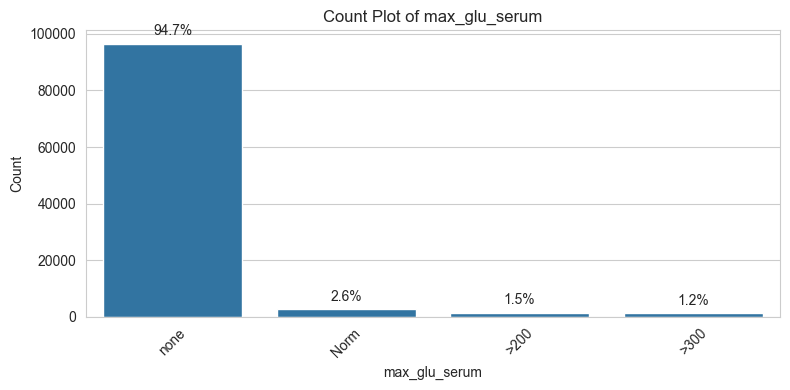

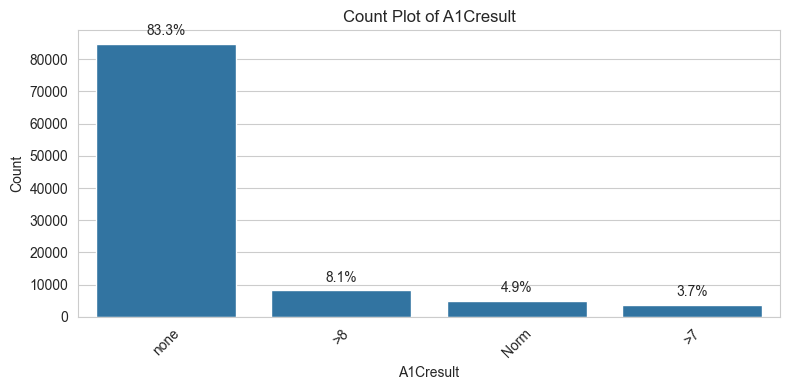

In [16]:
display_univariate_analysis(df_cleaned, None, categorical_groups['clinical'])

The clinical group comprises three diagnosis codes (`diag_1`, `diag_2`, `diag_3`) and two laboratory test result indicators (`max_glu_serum`, `A1Cresult`). Together, these features directly characterise the patient's medical condition at the time of admission and carry strong potential predictive signal for readmission risk.

**Diagnosis codes (diag_1, diag_2, diag_3).** All three diagnosis columns use ICD-9 coding and exhibit extremely high cardinality: 717, 749, and 790 unique values respectively. No single code dominates — the most frequent primary diagnosis (ICD-9 428, heart failure) accounts for only 6.7% of records, and the top five codes combined cover fewer than 27% of encounters. This degree of fragmentation means raw ICD-9 codes cannot be used directly in most models without incurring severe sparsity or cardinality penalties. The standard approach is to map codes to higher-level clinical chapters (e.g., circulatory, respiratory, diabetes-related, musculoskeletal). Cardiovascular codes (428 heart failure, 414 coronary artery disease, 410 acute MI) dominate `diag_1`, consistent with the known comorbidity burden in the diabetic inpatient population. Diabetes-specific and metabolic codes appear more strongly in secondary and tertiary positions — notably ICD-9 250 is the single most frequent code in `diag_3` (11.4%), suggesting that while diabetes is the defining chronic condition, it is often not the primary reason for the admission.

**Glucose serum test (max_glu_serum).** The overwhelming majority of encounters — 94.7% — have a value of `none`, meaning no serum glucose test was ordered during the stay. Among the 5.3% where the test was performed, results skew toward elevated readings: `>200` (1.5%) and `>300` (1.2%) together exceed the `Normal` category (2.6%). This near-universal absence is itself clinically informative: it may indicate that most admissions were not primarily metabolic crises, or that glucose monitoring practices varied widely across the 130 contributing hospitals. Because the untested state dominates, this feature will have limited discriminative power in its raw form. Encoding `none` as a binary `glucose_tested` flag and retaining the measured level as a separate ordinal feature will preserve the signal from the small but potentially high-risk tested subgroup.

**HbA1c test result (A1Cresult).** Similarly, 83.3% of encounters have no HbA1c result recorded. Among those tested, poorly controlled results are the most common outcome: `>8` (8.1%) exceeds both `Normal` (<7%, 4.9%) and borderline `>7` (3.7%). This pattern is clinically expected — HbA1c tends to be ordered precisely when glycaemic control is under active review, so the tested subgroup over-represents patients with known management challenges. The `>8` category may carry a meaningful readmission signal, but this requires bivariate confirmation. As with `max_glu_serum`, deriving a binary `A1C_tested` indicator alongside the categorical result will prevent the large `none` mass from dominating encoding and obscuring the predictive value of the measured outcomes.

**Treatment Status Group**

✓ Univariate Analysis for Categorical Columns:


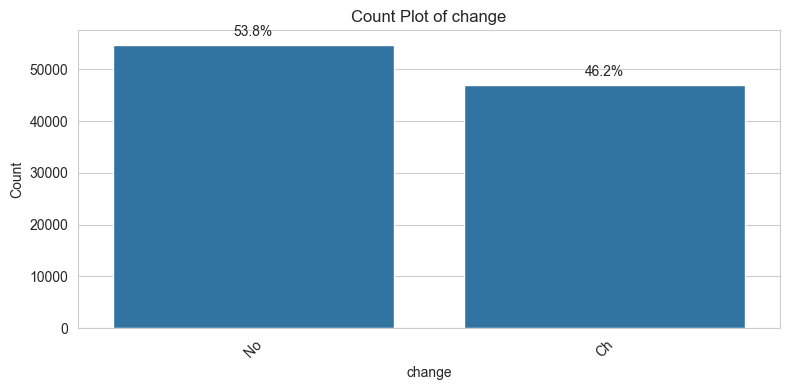

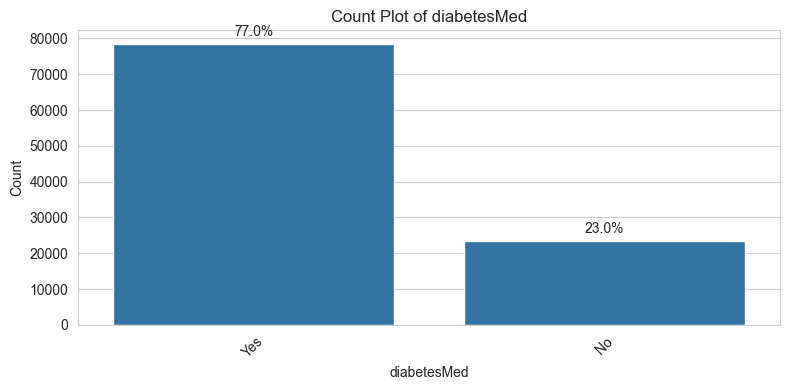

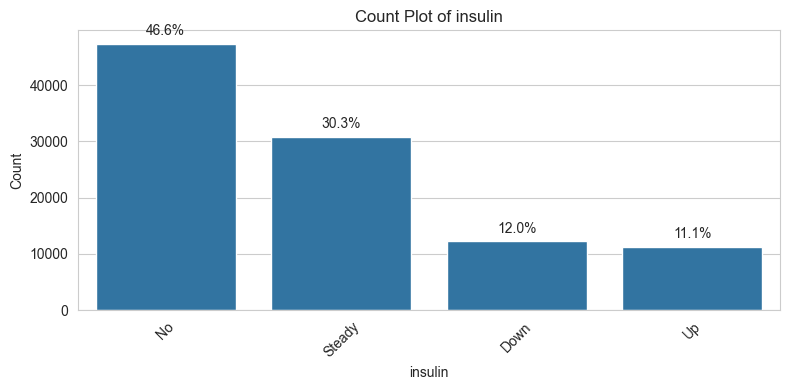

In [17]:
display_univariate_analysis(df_cleaned, None, categorical_groups['treatment_status'])

The treatment status group captures the state of the patient's diabetes management at the time of the encounter: whether any medication was changed (`change`), whether any diabetes medication was prescribed at all (`diabetesMed`), and the specific dosage trajectory of insulin (`insulin`). All three features are directly therapy-related and may carry meaningful signal for readmission risk, since poor or unstable glycaemic management is a known driver of return visits.

**Medication change (change).** The dataset is nearly evenly split between encounters where a medication change occurred (`Ch`, 46.2%) and those where it did not (`No`, 53.8%). This near-balance is noteworthy: a medication change during admission is typically a clinical response to suboptimal control, meaning the `Ch` group may contain patients with more poorly managed or actively deteriorating diabetes. At the same time, a change could reflect a positive adjustment reducing readmission risk. The binary distribution means this feature is straightforward to encode and will not suffer from class imbalance, but its directional relationship with the target requires bivariate investigation before assuming a sign.

**Diabetes medication prescribed (diabetesMed).** A clear majority of encounters (77.0%) had at least one diabetes medication prescribed, versus 23.0% without. The large `Yes` majority is expected given the nature of the dataset: these are hospitalised diabetic patients, and most would be on active pharmacotherapy. The minority `No` group may represent newly diagnosed patients, those managed by diet alone, or cases where medication was withheld for clinical reasons. Simple binary encoding (`Yes`/`No` → 1/0) is appropriate. Despite the imbalance, this feature may have limited standalone predictive power given how dominant the `Yes` category is across the full cohort; its contribution is more likely to emerge in interaction with other treatment variables.

**Insulin dosage trajectory (insulin).** With four categories, `insulin` is the most granular of the three features. Nearly half of encounters had no insulin prescribed (`No`, 46.6%). Among those on insulin, the majority maintained a steady dose (`Steady`, 30.3%), while dose reductions (`Down`, 12.0%) and increases (`Up`, 11.1%) were roughly equal in prevalence. The balance between `Down` and `Up` suggests that dose titration was not systematically directional across the population. For modeling, this feature is a candidate for ordinal encoding that encodes clinical change magnitude — one reasonable ordering would be `No` < `Steady` < `Down` or `Up`, though `Down` and `Up` may warrant separate treatment since both represent instability relative to `Steady`. Alternatively, deriving a binary `insulin_adjusted` flag (collapsing `Down` and `Up` into a single change indicator) would simplify encoding while preserving the key distinction between stable and actively modified regimens.

## Medication Feature Review

This section summarizes medication-related variables as a feature family. The goal is to identify which medication columns have meaningful variation, which are highly sparse, and which deserve deeper analysis against the target.

### Medication Summary Table

,medication,unique_values,pct_active_use,pct_no,pct_steady,pct_up,pct_down
0,metformin,4,19.64,80.36,18.03,1.05,0.57
1,glipizide,4,12.47,87.53,11.16,0.76,0.55
2,glyburide,4,10.47,89.53,9.11,0.80,0.55
3,pioglitazone,4,7.20,92.80,6.85,0.23,0.12
4,rosiglitazone,4,6.25,93.75,5.99,0.17,0.09
5,glimepiride,4,5.10,94.90,4.59,0.32,0.19
6,repaglinide,4,1.51,98.49,1.36,0.11,0.04
7,nateglinide,4,0.69,99.31,0.66,0.02,0.01
8,glyburide-metformin,4,0.69,99.31,0.68,0.01,0.01
9,acarbose,4,0.30,99.70,0.29,0.01,0.00


### Top 8 Medications by Active Use

,medication,unique_values,pct_active_use,pct_no,pct_steady,pct_up,pct_down
0,metformin,4,19.64,80.36,18.03,1.05,0.57
1,glipizide,4,12.47,87.53,11.16,0.76,0.55
2,glyburide,4,10.47,89.53,9.11,0.80,0.55
3,pioglitazone,4,7.20,92.80,6.85,0.23,0.12
4,rosiglitazone,4,6.25,93.75,5.99,0.17,0.09
5,glimepiride,4,5.10,94.90,4.59,0.32,0.19
6,repaglinide,4,1.51,98.49,1.36,0.11,0.04
7,nateglinide,4,0.69,99.31,0.66,0.02,0.01


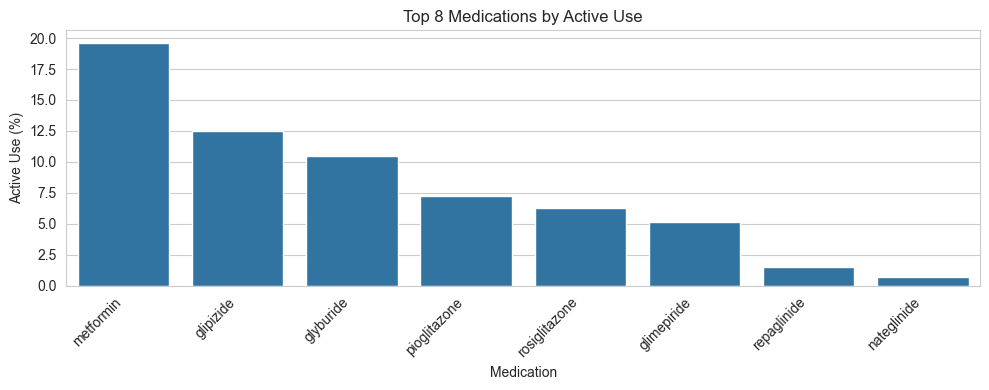

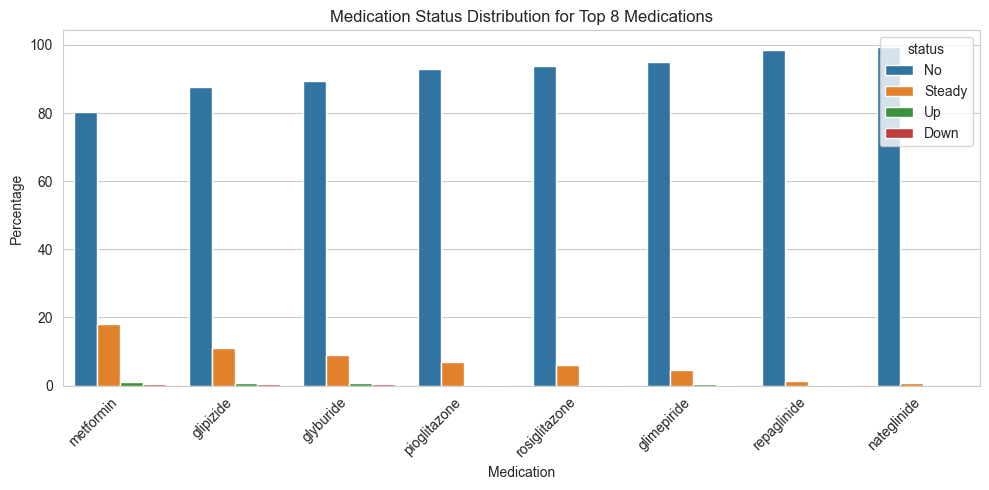

## Medication Features vs Target

Overall positive class rate (`readmitted = 1`): **11.16%**

Detailed target-wise analysis is restricted to medication variables with the greatest practical variation, based on active-use prevalence, plus any explicitly forced-in columns.

### Selected Medication Columns for Target Analysis

,medication,unique_values,pct_active_use,pct_no,pct_steady,pct_up,pct_down
0,metformin,4,19.64,80.36,18.03,1.05,0.57
1,glipizide,4,12.47,87.53,11.16,0.76,0.55
2,glyburide,4,10.47,89.53,9.11,0.80,0.55
3,pioglitazone,4,7.20,92.80,6.85,0.23,0.12
4,rosiglitazone,4,6.25,93.75,5.99,0.17,0.09
5,glimepiride,4,5.10,94.90,4.59,0.32,0.19
6,repaglinide,4,1.51,98.49,1.36,0.11,0.04
7,nateglinide,4,0.69,99.31,0.66,0.02,0.01


...

readmitted,0,1
metformin,,
Down,506,69
No,72360,9418
Steady,16564,1782
Up,979,88


**Row Percentage Table**

readmitted,0,1
metformin,,
Down,88.00,12.00
No,88.48,11.52
Steady,90.29,9.71
Up,91.75,8.25


**Positive Class Rate and Lift vs Baseline**

,metformin,positive_rate_pct,lift_vs_baseline
0,Down,12.000,1.075
1,No,11.517,1.032
2,Steady,9.713,0.870
3,Up,8.247,0.739


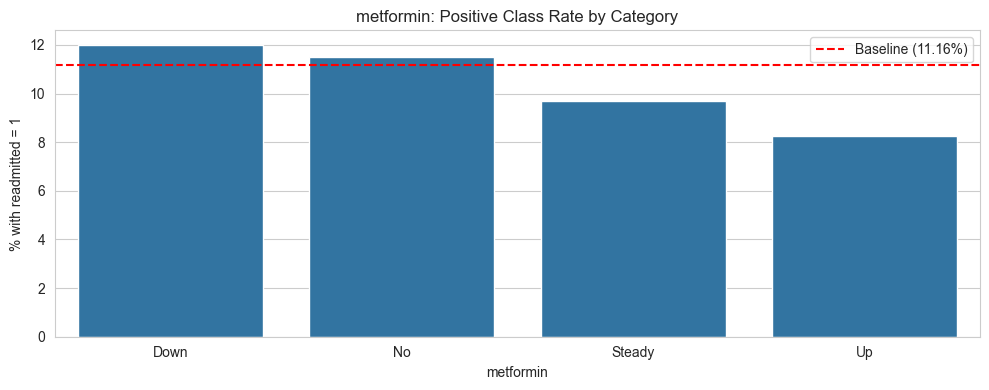

### glipizide

**Count Table**

readmitted,0,1
glipizide,,
Down,475,85
No,79175,9905
Steady,10088,1268
Up,671,99


**Row Percentage Table**

readmitted,0,1
glipizide,,
Down,84.82,15.18
No,88.88,11.12
Steady,88.83,11.17
Up,87.14,12.86


**Positive Class Rate and Lift vs Baseline**

,glipizide,positive_rate_pct,lift_vs_baseline
0,Down,15.179,1.360
3,Up,12.857,1.152
2,Steady,11.166,1.001
1,No,11.119,0.996


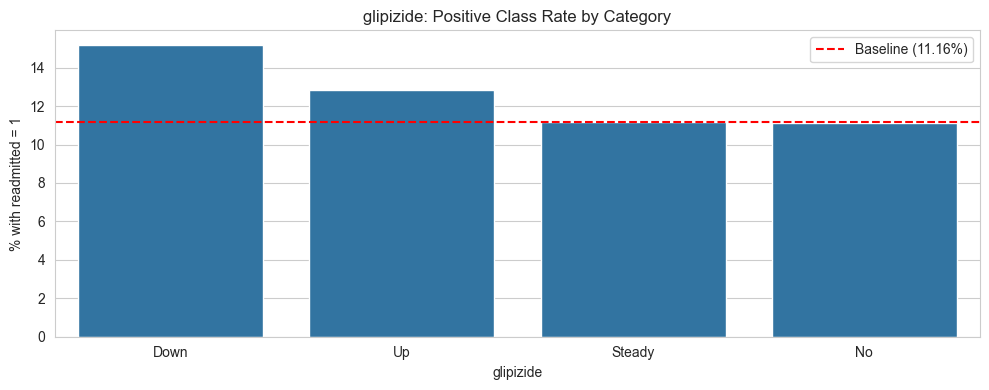

### glyburide

**Count Table**

readmitted,0,1
glyburide,,
Down,512,52
No,80891,10225
Steady,8279,995
Up,727,85


**Row Percentage Table**

readmitted,0,1
glyburide,,
Down,90.78,9.22
No,88.78,11.22
Steady,89.27,10.73
Up,89.53,10.47


**Positive Class Rate and Lift vs Baseline**

,glyburide,positive_rate_pct,lift_vs_baseline
1,No,11.222,1.006
2,Steady,10.729,0.961
3,Up,10.468,0.938
0,Down,9.220,0.826


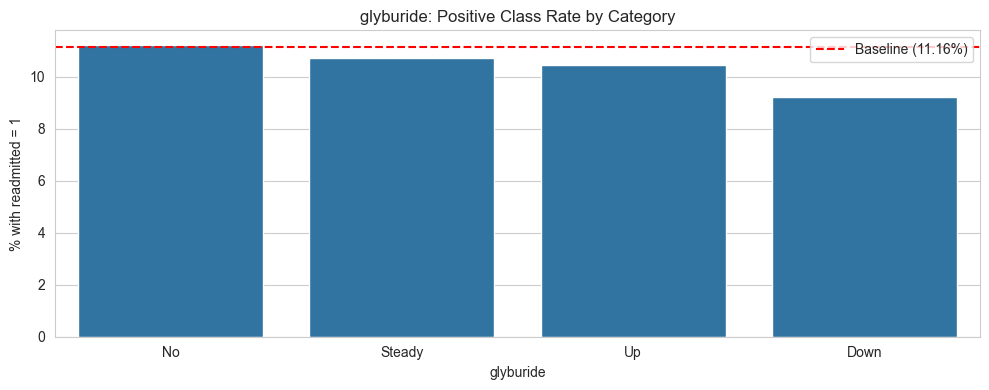

### pioglitazone

**Count Table**

readmitted,0,1
pioglitazone,,
Down,100,18
No,83855,10583
Steady,6249,727
Up,205,29


**Row Percentage Table**

readmitted,0,1
pioglitazone,,
Down,84.75,15.25
No,88.79,11.21
Steady,89.58,10.42
Up,87.61,12.39


**Positive Class Rate and Lift vs Baseline**

,pioglitazone,positive_rate_pct,lift_vs_baseline
0,Down,15.254,1.367
3,Up,12.393,1.111
1,No,11.206,1.004
2,Steady,10.421,0.934


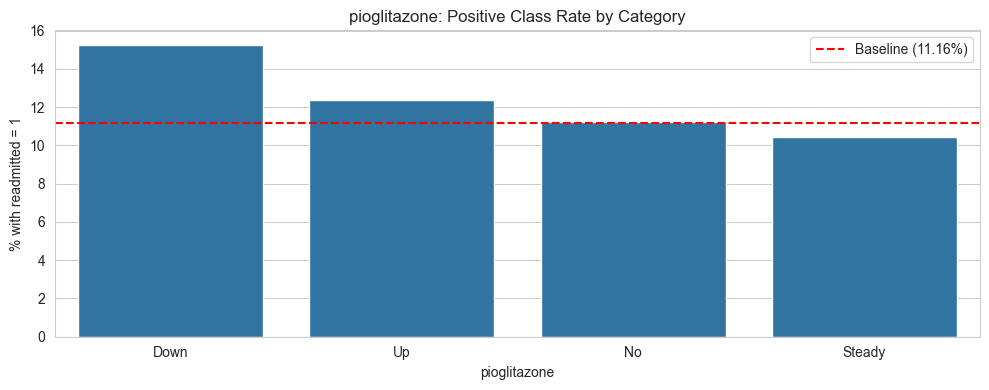

### rosiglitazone

**Count Table**

readmitted,0,1
rosiglitazone,,
Down,82,5
No,84709,10692
Steady,5459,641
Up,159,19


**Row Percentage Table**

readmitted,0,1
rosiglitazone,,
Down,94.25,5.75
No,88.79,11.21
Steady,89.49,10.51
Up,89.33,10.67


**Positive Class Rate and Lift vs Baseline**

,rosiglitazone,positive_rate_pct,lift_vs_baseline
1,No,11.207,1.004
3,Up,10.674,0.956
2,Steady,10.508,0.942
0,Down,5.747,0.515


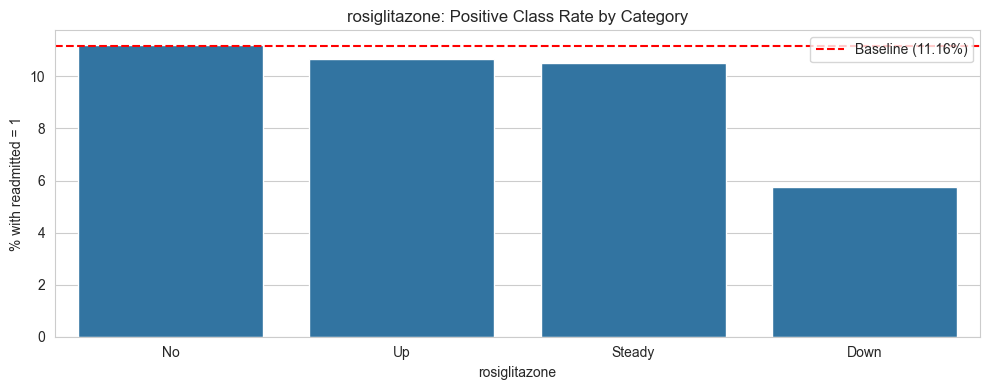

### glimepiride

**Count Table**

readmitted,0,1
glimepiride,,
Down,169,25
No,85748,10827
Steady,4202,468
Up,290,37


**Row Percentage Table**

readmitted,0,1
glimepiride,,
Down,87.11,12.89
No,88.79,11.21
Steady,89.98,10.02
Up,88.69,11.31


**Positive Class Rate and Lift vs Baseline**

,glimepiride,positive_rate_pct,lift_vs_baseline
0,Down,12.887,1.155
3,Up,11.315,1.014
1,No,11.211,1.005
2,Steady,10.021,0.898


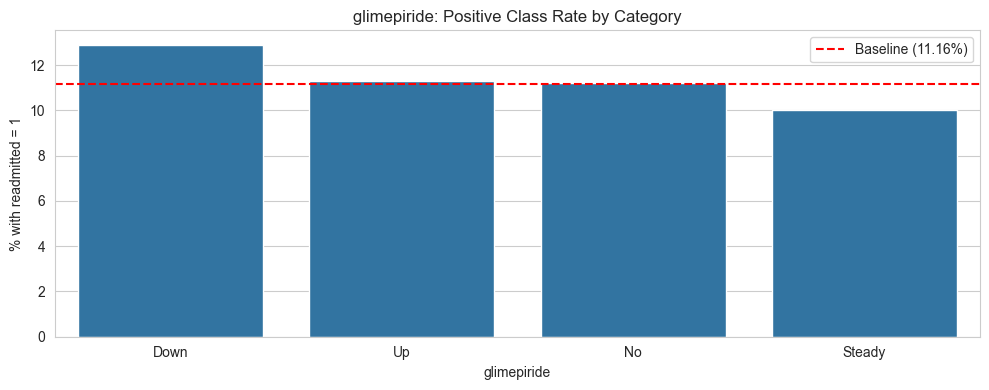

### repaglinide

**Count Table**

readmitted,0,1
repaglinide,,
Down,42,3
No,89075,11152
Steady,1202,182
Up,90,20


**Row Percentage Table**

readmitted,0,1
repaglinide,,
Down,93.33,6.67
No,88.87,11.13
Steady,86.85,13.15
Up,81.82,18.18


**Positive Class Rate and Lift vs Baseline**

,repaglinide,positive_rate_pct,lift_vs_baseline
3,Up,18.182,1.629
2,Steady,13.150,1.178
1,No,11.127,0.997
0,Down,6.667,0.597


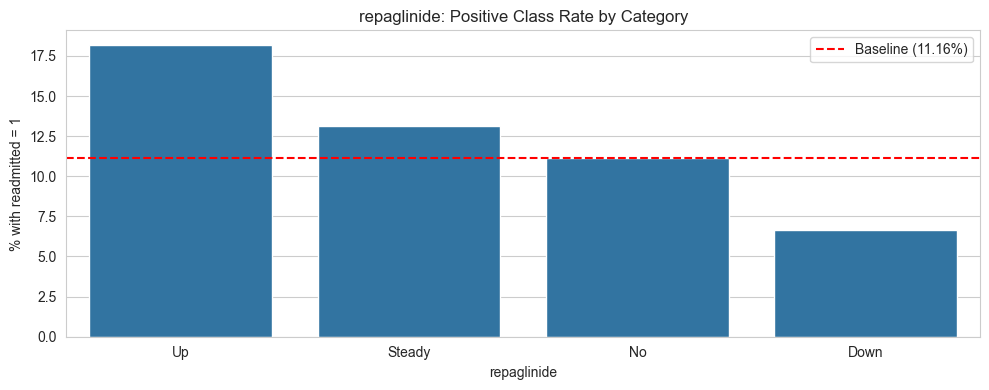

### nateglinide

**Count Table**

readmitted,0,1
nateglinide,,
Down,10,1
No,89786,11277
Steady,590,78
Up,23,1


**Row Percentage Table**

readmitted,0,1
nateglinide,,
Down,90.91,9.09
No,88.84,11.16
Steady,88.32,11.68
Up,95.83,4.17


**Positive Class Rate and Lift vs Baseline**

,nateglinide,positive_rate_pct,lift_vs_baseline
2,Steady,11.677,1.046
1,No,11.158,1.000
0,Down,9.091,0.815
3,Up,4.167,0.373


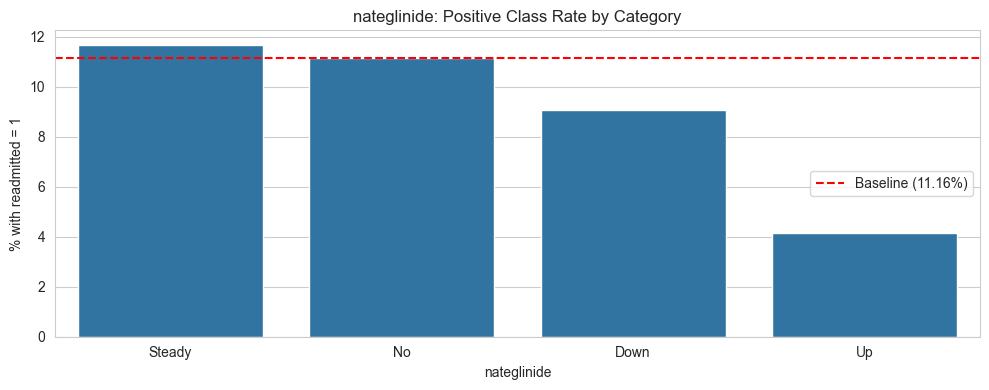

In [18]:
display_medication_eda(df_cleaned, categorical_groups['medication_features'], target_col=target)

The medication feature group encompasses 20 oral and injectable antidiabetic agents. Each variable encodes the dosage trajectory of a given drug during the hospital encounter using four categories: No (not prescribed), Steady (prescribed, dose unchanged), Up (dose increased), and Down (dose decreased). The baseline readmission rate across the full cohort is 11.16%.

**Sparsity and active-use distribution.** Active use — any prescription status other than No — varies enormously across the 20 medications. Metformin is by far the most commonly prescribed agent (19.64% active), followed by glipizide (12.47%) and glyburide (10.47%). A steep drop-off follows: pioglitazone (7.20%), rosiglitazone (6.25%), and glimepiride (5.10%) form a middle tier, while repaglinide (1.51%) and nateglinide (0.69%) retain marginal but non-negligible use. The remaining 12 medications — including acarbose, chlorpropamide, miglitol, tolazamide, and all combination agents — have ≤ 0.04% active use, making them effectively near-constant variables with no practical discriminative power. Among active users, the Steady category strongly dominates in every medication: dose adjustments (Up or Down) account for only a small fraction of active encounters, with Up and Down shares rarely exceeding 1–2% individually.

**Bivariate patterns: no uniform dose-adjustment effect.** The relationship between dosage trajectory and readmission is heterogeneous across medications, which undermines any single pooled narrative. Several distinct patterns emerge:

- **Bidirectional adjustment signals instability** (glipizide, pioglitazone): Both Down and Up are associated with elevated readmission, consistent with the interpretation that any dose change — regardless of direction — reflects glycaemic instability. For glipizide, Down reaches 15.18% (lift 1.360) and Up 12.86% (lift 1.152). For pioglitazone, Down is 15.25% (lift 1.367) and Up 12.39% (lift 1.111). In both cases, Steady patients remain close to baseline.

- **Upward adjustment is the primary risk signal** (repaglinide, glimepiride): Repaglinide shows a particularly strong gradient — Up reaches 18.18% (lift 1.629) and Steady 13.15% (lift 1.178), while Down is markedly below baseline at 6.67% (lift 0.597). Glimepiride shows a milder version of the same Up/Down asymmetry: Down is 12.89% (lift 1.155), Up is 11.32% (lift 1.014), with Steady below baseline.

- **Relatively flat across categories** (glyburide): All four categories hover near the 11.16% baseline, with No slightly elevated at 11.22% and Down actually the lowest at 9.22% (lift 0.826). This medication shows no clinically interpretable differentiation across dosage states.

- **Active use appears protective against readmission** (metformin): Counterintuitively, patients on a steady metformin dose have a lower readmission rate (9.71%, lift 0.870) than patients not prescribed metformin at all (11.52%, lift 1.032). Patients with a dose increase show the lowest rate of all at 8.25% (lift 0.739). This likely reflects the confounding effect of newly diagnosed or insulin-dependent patients in the No group rather than a causal protective effect of metformin.

- **Anomalous or noisy** (rosiglitazone, nateglinide): Rosiglitazone shows a striking outlier — Down has a readmission rate of only 5.75% (lift 0.515), substantially below all other categories, but this subgroup contains only 87 patients and the result should not be over-interpreted. Nateglinide data are similarly thin, with the Up category based on just 24 patients.

**Implication for feature engineering.** Two key engineering decisions are directly informed by these findings. First, the 12 near-constant medications (≤ 0.04% active use) should be dropped or consolidated into aggregate counts, as they offer no meaningful signal and risk adding noise or overfitting. Second, a simple shared ordinal encoding (No→0, Steady→1, dose-changed→2) is a reasonable simplification that captures the general signal — active use, and the further distinction between stable and adjusted dosing — without attempting to model the heterogeneous and sometimes noise-dominated direction effects (Up vs Down) individually in each drug column. For the two drugs showing the strongest and most interpretable bivariate signal (glipizide, pioglitazone, repaglinide), this encoding will preserve the dominant adjustment effect; for flat medications like glyburide, the feature will contribute minimal noise. The encoded medication columns should be retained alongside the `insulin_adjusted` and `diabetesMed` treatment-status flags to give the model access to both individual-drug and composite treatment-state signals.


### Bivariate analysis

The bivariate analysis will examine the relationship between the target variable (`readmitted`) and key features — covering all eight numerical columns and a curated selection of categorical columns. For categorical features, selection was guided by the univariate findings: variables with clinically meaningful distributions, sufficient category coverage, or known risk associations were prioritised. The three high-cardinality diagnosis columns (`diag_1`, `diag_2`, `diag_3`) are excluded at this stage — with 717–790 unique ICD-9 codes each, they require chapter-level grouping before any meaningful bivariate comparison is possible.

**Demographic & administrative features:**

- **`race`** — Essential for examining differential readmission rates across racial groups and for downstream fairness evaluation; the heavy Caucasian skew (74.8%) makes disparate-impact assessment mandatory.
- **`gender`** — The near-even split (53.8% female / 46.2% male) provides a clean, interpretable comparison of sex-based readmission differences.
- **`age`** — Strong a priori candidate: ~67% of patients are aged 60+ and readmission risk is expected to follow a monotonic age gradient in this diabetic inpatient population.
- **`admission_type_id`** — Emergency admissions dominate (53.1%) and represent higher-acuity encounters; comparing readmission rates between emergency, urgent, and elective admissions tests whether admission severity is a meaningful risk differentiator.
- **`discharge_disposition_id`** — The univariate analysis flagged code 11 (Expired, 1.6%) as a leakage risk; bivariate analysis is needed to confirm this concern and to assess whether discharge destination (home vs. facility transfer) separates readmission risk.
- **`admission_source_id`** — ER-sourced admissions (56.5%) were identified as a plausible proxy for illness severity; quantifying their readmission rate relative to physician referrals and other sources will validate this hypothesis.
- **`medical_specialty`** — Included with a caveat: 49.1% of records have `Unknown` specialty, so the analysis will focus on the known specialties and a `specialty_known` binary flag should be evaluated alongside the grouped label.

**Clinical features:**

- **`max_glu_serum`** — Included despite 94.7% `none` values; the small tested subgroup skews toward elevated readings (`>200`, `>300`) that may carry a clinically meaningful readmission signal worth quantifying.
- **`A1Cresult`** — Similarly included despite 83.3% `none`; the `>8` group (8.1%) represents poorly controlled diabetes and is the most clinically actionable category to compare against the target.

**Treatment status features:**

- **`change`** — Near-even split (53.8% / 46.2%) makes this a strong candidate; whether in-hospital medication adjustment correlates positively or negatively with readmission is an open and important clinical question.
- **`diabetesMed`** — Included to confirm whether active pharmacotherapy status differentiates readmission risk, acknowledging that the dominant `Yes` category (77.0%) may limit the observable effect size.
- **`insulin`** — The most granular treatment variable with four categories; particular interest lies in whether dose adjustments (`Up`, `Down`) are associated with higher readmission compared to stable (`Steady`) or no-insulin (`No`) patients.

## Bivariate Analysis: Numerical Features vs Target

### time_in_hospital

,0,1
mean,4.349,4.768
median,4.000,4.000


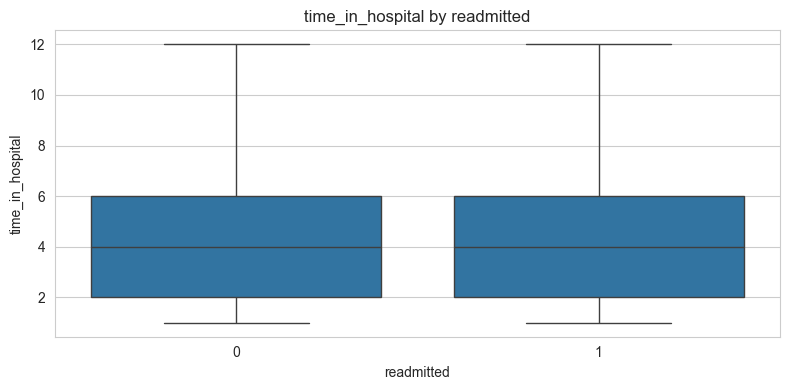

### num_lab_procedures

,0,1
mean,42.954,44.226
median,44.000,45.000


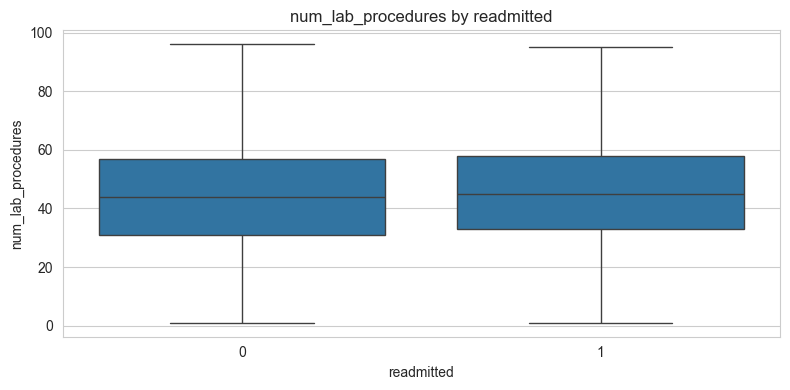

### num_procedures

**Auto plot selection:** `num_procedures` is zero-inflated (45.8% zeros), so a histogram is used.

,0,1
mean,1.347,1.281
median,1.000,1.000


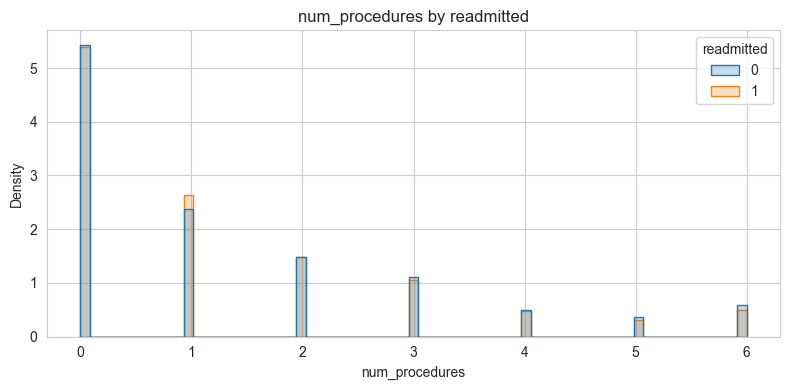

### num_medications

,0,1
mean,15.911,16.903
median,15.000,16.000


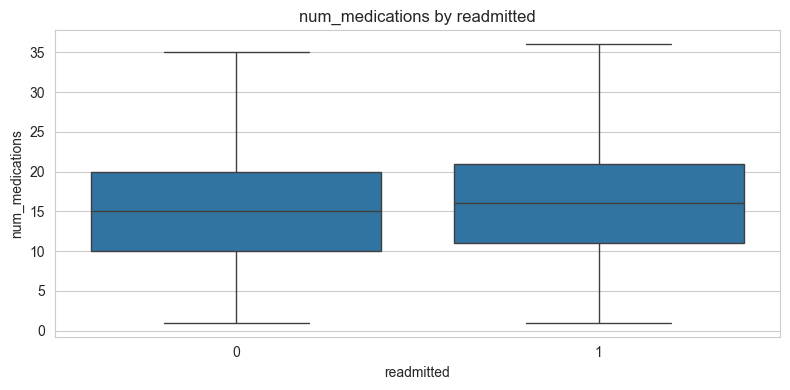

### number_outpatient

**Auto plot selection:** `number_outpatient` is zero-inflated (83.6% zeros), so a histogram is used.

,0,1
mean,0.361,0.437
median,0.000,0.000


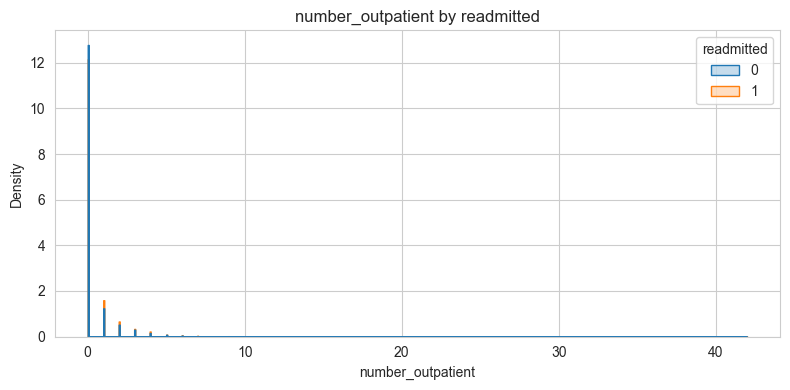

### number_emergency

**Auto plot selection:** `number_emergency` is zero-inflated (88.8% zeros), so a histogram is used.

,0,1
mean,0.178,0.357
median,0.000,0.000


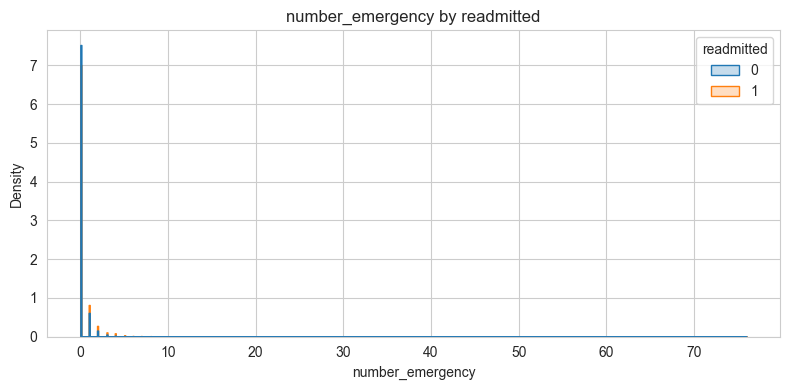

### number_inpatient

**Auto plot selection:** `number_inpatient` is zero-inflated (66.5% zeros), so a histogram is used.

,0,1
mean,0.562,1.224
median,0.000,0.000


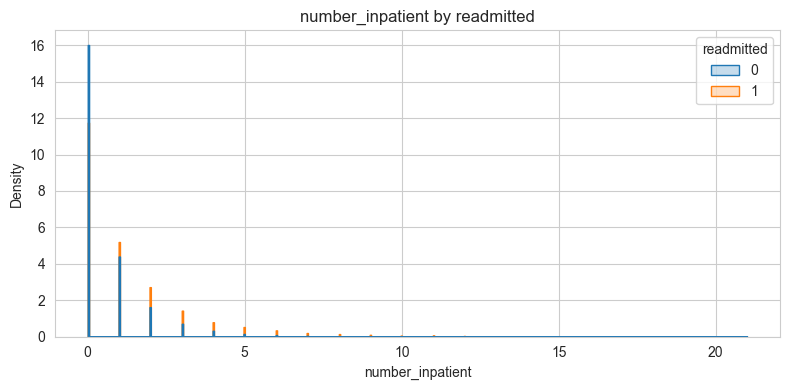

### number_diagnoses

,0,1
mean,7.389,7.693
median,8.000,9.000


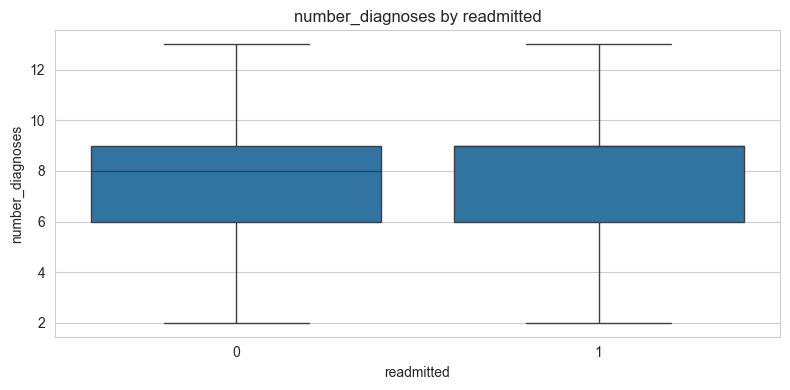

## Numerical Summary Table

,mean_0,mean_1,median_0,median_1,diff,pct_diff,zero_ratio
feature,,,,,,,
time_in_hospital,4.349,4.768,4.0,4.0,0.419,9.634,0.00
num_lab_procedures,42.954,44.226,44.0,45.0,1.272,2.961,0.00
num_procedures,1.347,1.281,1.0,1.0,-0.066,-4.900,45.84
num_medications,15.911,16.903,15.0,16.0,0.992,6.235,0.00
number_outpatient,0.361,0.437,0.0,0.0,0.076,21.053,83.55
number_emergency,0.178,0.357,0.0,0.0,0.179,100.562,88.81
number_inpatient,0.562,1.224,0.0,0.0,0.662,117.794,66.46
number_diagnoses,7.389,7.693,8.0,9.0,0.304,4.114,0.00


In [19]:
display_bivariate_analysis(df_cleaned, target, numerical_columns)

The summary table and visualisations reveal a clear split between features with meaningful separation across the two readmission classes and those that are effectively flat. Note that four features crossed the 30% zero-inflation threshold and were automatically displayed as density histograms rather than boxplots: `number_outpatient` (83.6% zeros), `number_emergency` (88.8%), `number_inpatient` (66.5%), and `num_procedures` (45.8%).

**Prior utilisation variables dominate.** `number_inpatient` and `number_emergency` are the strongest numerical differentiators by a wide margin. Patients readmitted within 30 days had a mean prior inpatient visit count 117.9% higher than non-readmitted patients (0.562 vs 1.224), and a mean prior emergency visit count 100.6% higher (0.178 vs 0.357). Given that 66.5% and 88.8% of values in these columns are zero respectively, the absolute differences are modest in magnitude, but the relative signal is substantial and persistent — and the histogram plots confirm that readmitted patients have a visibly heavier right tail on the non-zero portion of both distributions. `number_outpatient` shows a more moderate 21.1% relative difference (0.361 vs 0.437) despite 83.6% zero inflation. Taken together, the prior utilisation trio tells a coherent clinical story: frequent prior hospitalisations and emergency visits are strong markers of high-acuity, poorly controlled disease — exactly the patient profile associated with rapid readmission.

**Current-encounter variables show weak but consistent trends.** `time_in_hospital` is 9.6% higher on average for readmitted patients (4.349 vs 4.768 days), and `num_medications` is 6.2% higher (15.9 vs 16.9). Both suggest that readmitted patients tend to have more complex and resource-intensive admissions, but neither column is zero-inflated (zero ratio = 0.0% for both), so the boxplots faithfully represent the full distribution — and the spreads overlap heavily. `number_diagnoses` (+4.1%) and `num_lab_procedures` (+3.0%) show only marginal mean differences and essentially identical medians, with next to no zero-inflation. These features will likely contribute minimal standalone signal in any model.

**`num_procedures` is the only feature trending in the opposite direction**, with readmitted patients averaging 4.9% fewer procedures than non-readmitted patients (1.347 vs 1.281). Its 45.8% zero ratio triggered histogram display; the density plots show very similar distributions between classes, with the slight negative direction most plausibly explained by the acuity profile of readmitted patients — those at highest risk may be too unstable for elective or planned procedures, or procedure-heavy encounters may disproportionately represent surgical cases with lower baseline readmission rates.

**Modeling implications.** The prior utilisation trio (`number_inpatient`, `number_emergency`, `number_outpatient`) should be treated as high-priority features. Their extreme zero inflation suggests that a binary `had_prior_inpatient` flag — and analogous flags for emergency and outpatient — may capture much of the separating signal cleanly alongside the raw count. For linear models, log1p transformation will compress the long right tail; for tree-based models, raw values are usable as-is. The current-encounter variables contribute modest additive signal and should be retained, but their limited marginal discriminability means the model will rely on them only in combination with stronger predictors. `num_procedures` is unlikely to be a meaningful predictor in its current form and may perform best as a binary `had_procedures` flag.

## Bivariate Analysis: Categorical Features vs Target

### race

**Count Table**

readmitted,0,1
race,,
AfricanAmerican,17055,2155
Asian,576,65
Caucasian,67507,8592
Hispanic,1825,212
Other,1361,145
Unknown,2085,188


**Row Percentage Table**

readmitted,0,1
race,,
AfricanAmerican,88.78,11.22
Asian,89.86,10.14
Caucasian,88.71,11.29
Hispanic,89.59,10.41
Other,90.37,9.63
Unknown,91.73,8.27


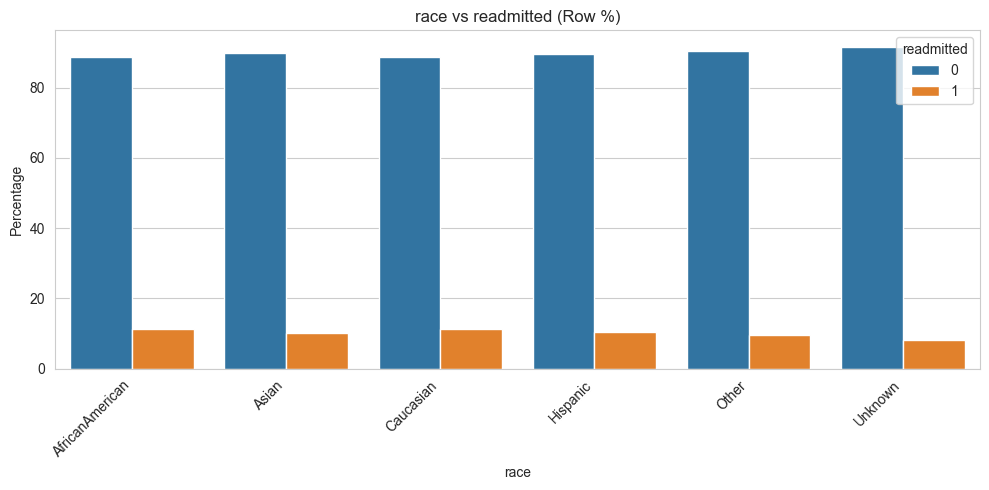

### gender

**Count Table**

readmitted,0,1
gender,,
Female,48556,6152
Male,41850,5205
Unknown/Invalid,3,0


**Row Percentage Table**

readmitted,0,1
gender,,
Female,88.75,11.25
Male,88.94,11.06
Unknown/Invalid,100.00,0.00


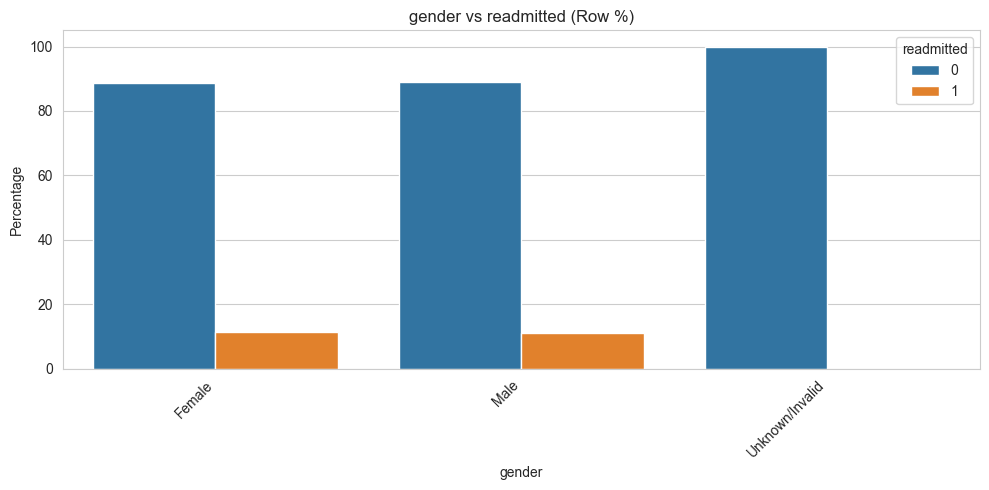

### age

**Count Table**

readmitted,0,1
age,,
[0-10),158,3
[10-20),651,40
[20-30),1421,236
[30-40),3351,424
[40-50),8658,1027
[50-60),15588,1668
[60-70),19981,2502
[70-80),22999,3069
[80-90),15119,2078


**Row Percentage Table**

readmitted,0,1
age,,
[0-10),98.14,1.86
[10-20),94.21,5.79
[20-30),85.76,14.24
[30-40),88.77,11.23
[40-50),89.40,10.60
[50-60),90.33,9.67
[60-70),88.87,11.13
[70-80),88.23,11.77
[80-90),87.92,12.08


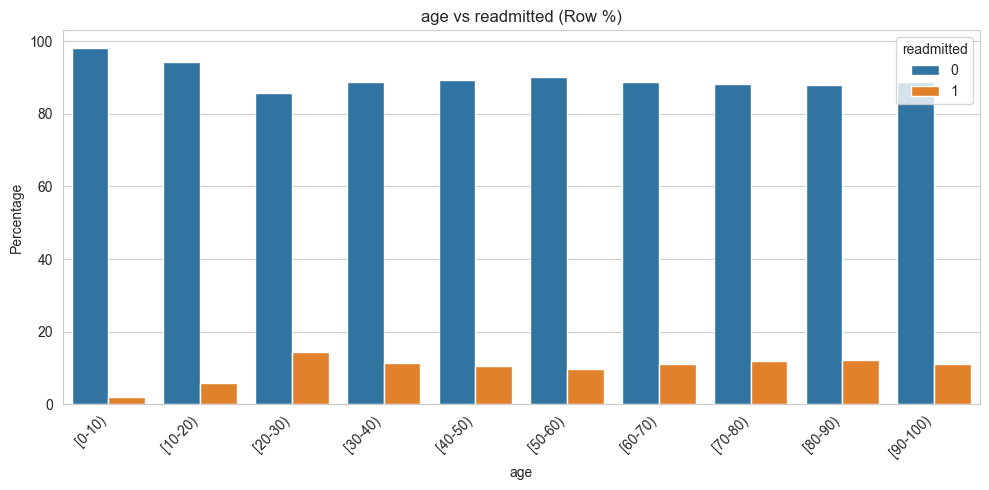

### admission_type_id

**Count Table**

readmitted,0,1
admission_type_id,,
1,47769,6221
2,16414,2066
3,16908,1961
4,9,1
5,4290,495
6,4705,586
7,21,0
8,293,27


**Row Percentage Table**

readmitted,0,1
admission_type_id,,
1,88.48,11.52
2,88.82,11.18
3,89.61,10.39
4,90.00,10.00
5,89.66,10.34
6,88.92,11.08
7,100.00,0.00
8,91.56,8.44


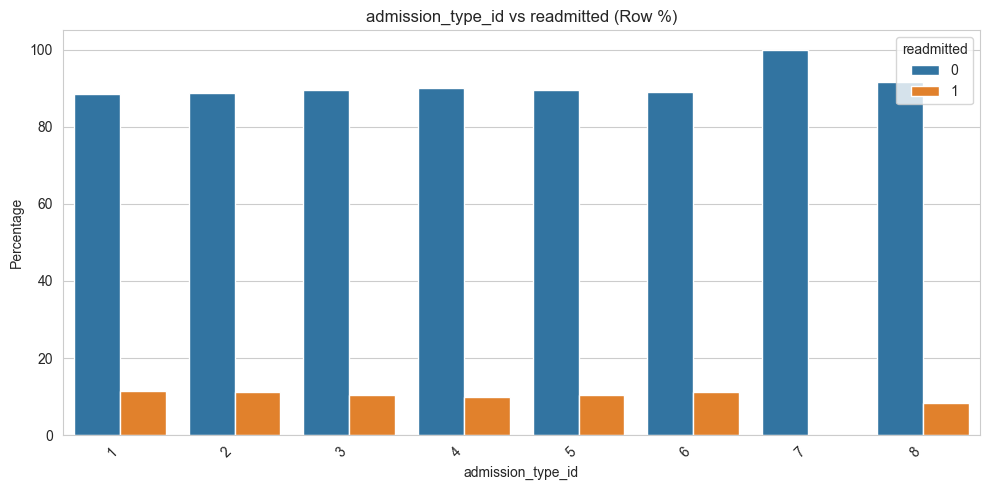

### discharge_disposition_id

**Count Table**

readmitted,0,1
discharge_disposition_id,,
1,54632,5602
11,1642,0
18,3232,459
2,1786,342
22,1441,552
25,897,92
3,11908,2046
4,711,104
5,937,247


**Row Percentage Table**

readmitted,0,1
discharge_disposition_id,,
1,90.70,9.30
11,100.00,0.00
18,87.56,12.44
2,83.93,16.07
22,72.30,27.70
25,90.70,9.30
3,85.34,14.66
4,87.24,12.76
5,79.14,20.86


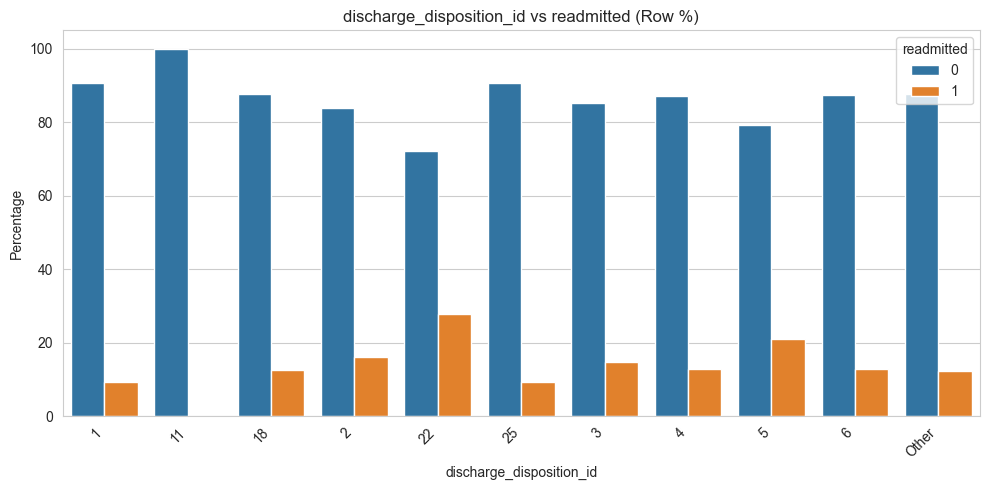

### admission_source_id

**Count Table**

readmitted,0,1
admission_source_id,,
1,26435,3130
17,6075,706
2,993,111
20,139,22
3,158,29
4,2878,309
5,754,101
6,2052,212
7,50774,6720


**Row Percentage Table**

readmitted,0,1
admission_source_id,,
1,89.41,10.59
17,89.59,10.41
2,89.95,10.05
20,86.34,13.66
3,84.49,15.51
4,90.30,9.70
5,88.19,11.81
6,90.64,9.36
7,88.31,11.69


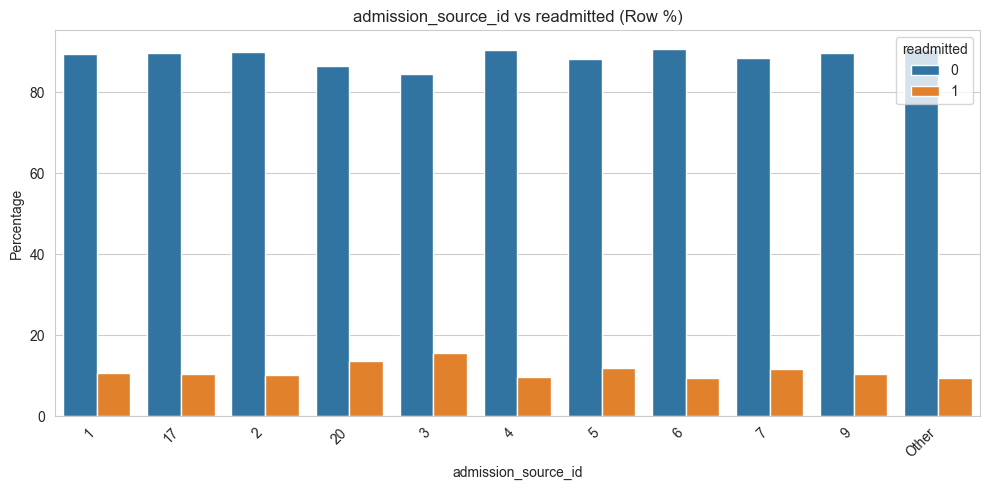

### medical_specialty

**Count Table**

readmitted,0,1
medical_specialty,,
Cardiology,4927,425
Emergency/Trauma,6719,846
Family/GeneralPractice,6557,883
InternalMedicine,12989,1646
Nephrology,1365,248
Orthopedics,1249,151
Orthopedics-Reconstructive,1141,92
Other,7500,840
Radiologist,1037,103


**Row Percentage Table**

readmitted,0,1
medical_specialty,,
Cardiology,92.06,7.94
Emergency/Trauma,88.82,11.18
Family/GeneralPractice,88.13,11.87
InternalMedicine,88.75,11.25
Nephrology,84.62,15.38
Orthopedics,89.21,10.79
Orthopedics-Reconstructive,92.54,7.46
Other,89.93,10.07
Radiologist,90.96,9.04


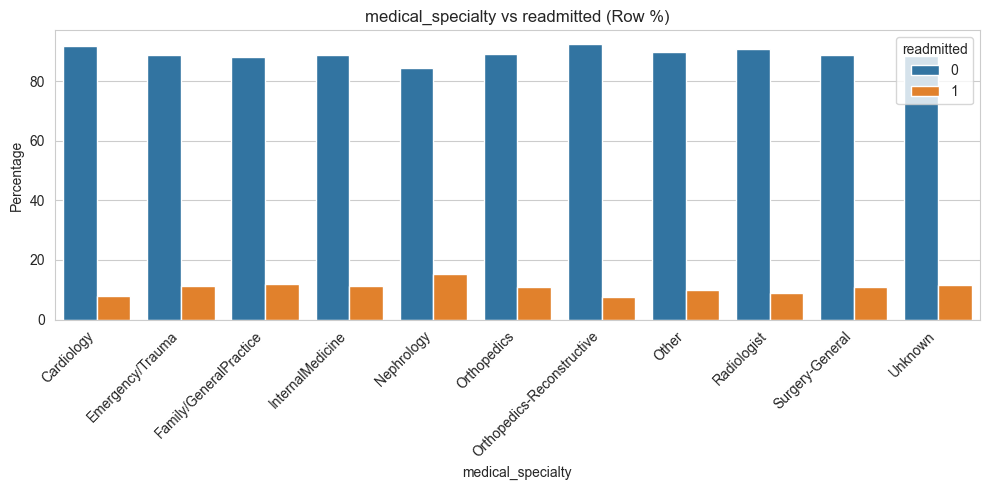

### max_glu_serum

**Count Table**

readmitted,0,1
max_glu_serum,,
>200,1300,185
>300,1083,181
Norm,2302,295
none,85724,10696


**Row Percentage Table**

readmitted,0,1
max_glu_serum,,
>200,87.54,12.46
>300,85.68,14.32
Norm,88.64,11.36
none,88.91,11.09


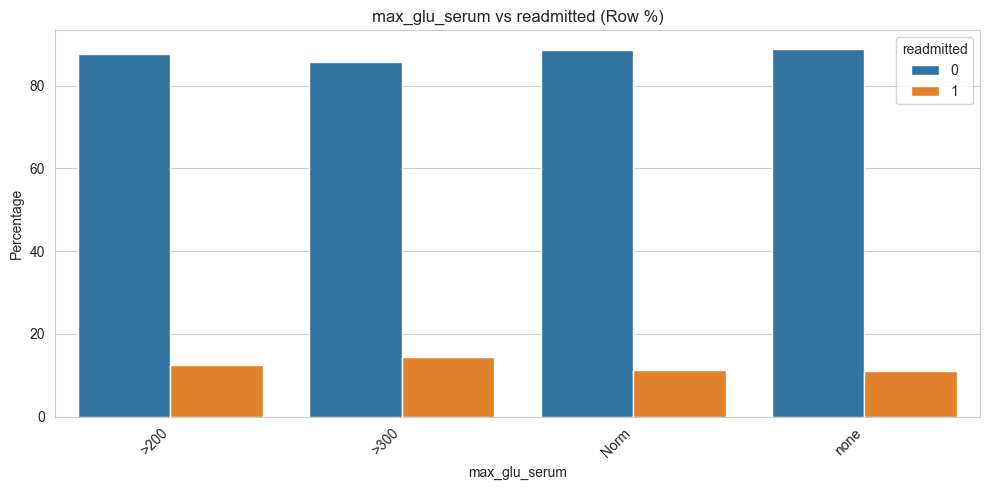

### A1Cresult

**Count Table**

readmitted,0,1
A1Cresult,,
>7,3429,383
>8,7405,811
Norm,4508,482
none,75067,9681


**Row Percentage Table**

readmitted,0,1
A1Cresult,,
>7,89.95,10.05
>8,90.13,9.87
Norm,90.34,9.66
none,88.58,11.42


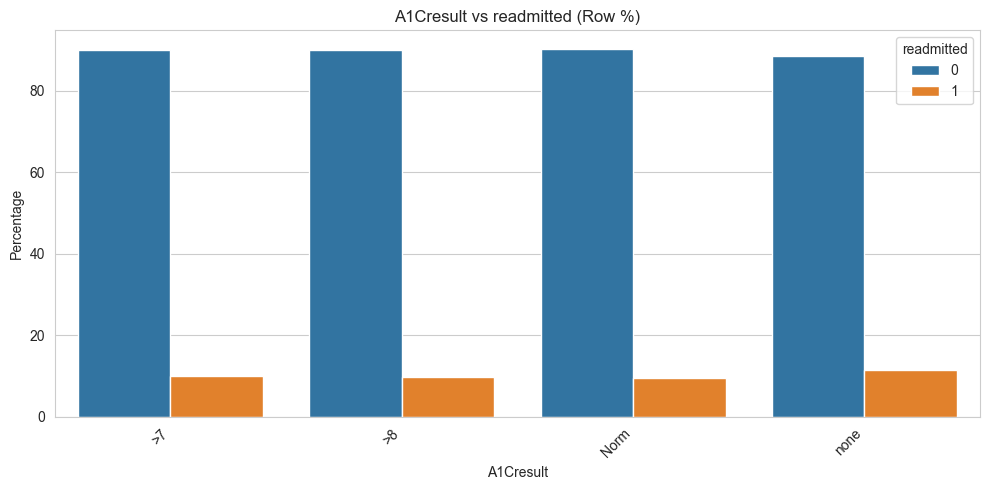

### change

**Count Table**

readmitted,0,1
change,,
Ch,41453,5558
No,48956,5799


**Row Percentage Table**

readmitted,0,1
change,,
Ch,88.18,11.82
No,89.41,10.59


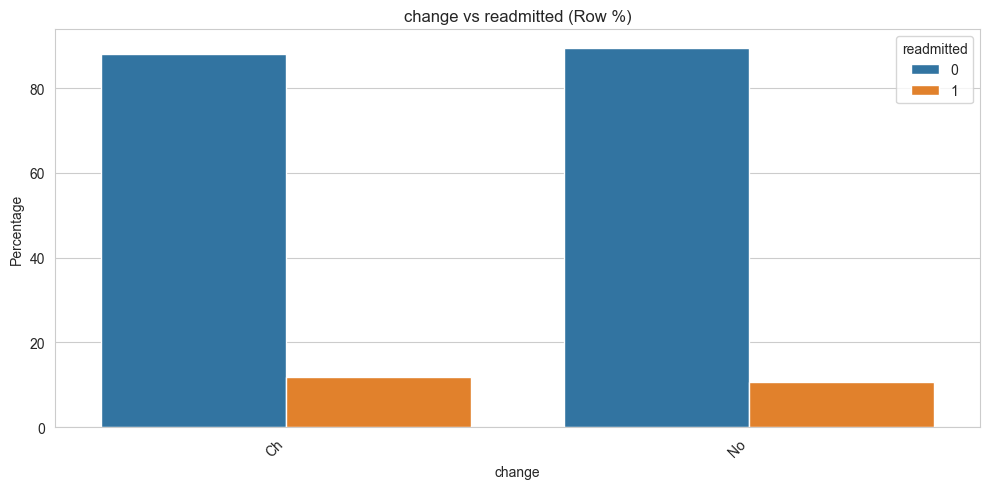

### diabetesMed

**Count Table**

readmitted,0,1
diabetesMed,,
No,21157,2246
Yes,69252,9111


**Row Percentage Table**

readmitted,0,1
diabetesMed,,
No,90.40,9.60
Yes,88.37,11.63


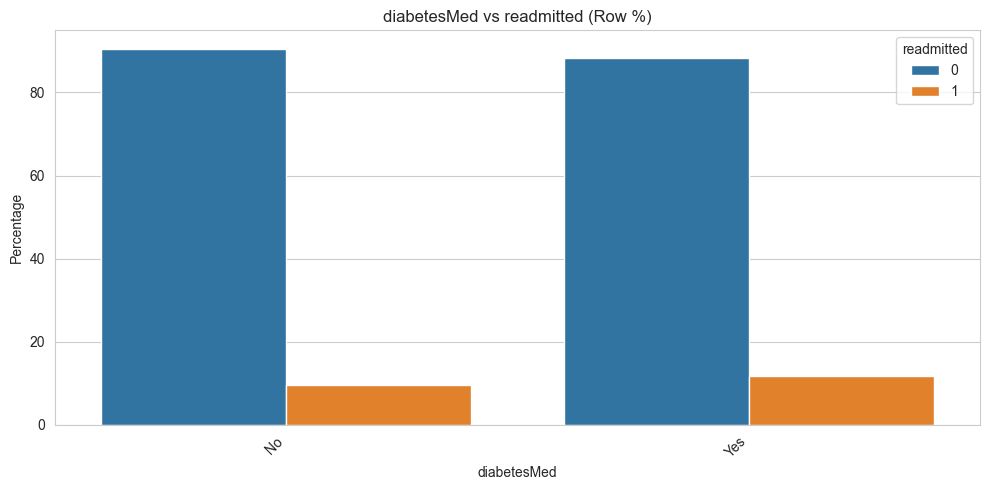

### insulin

**Count Table**

readmitted,0,1
insulin,,
Down,10520,1698
No,42627,4756
Steady,27416,3433
Up,9846,1470


**Row Percentage Table**

readmitted,0,1
insulin,,
Down,86.10,13.90
No,89.96,10.04
Steady,88.87,11.13
Up,87.01,12.99


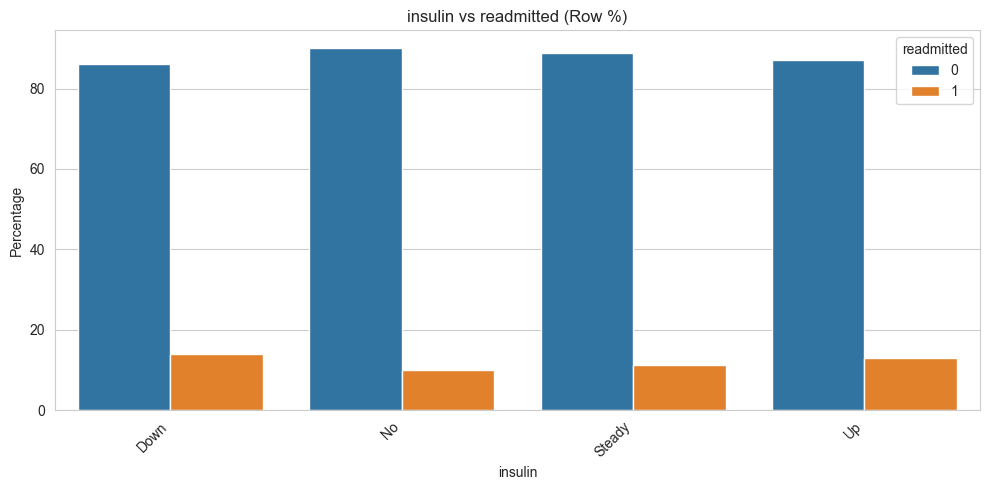

In [20]:
categorical_bivariate_columns = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'insulin']
display_bivariate_analysis(df_cleaned, target, None, categorical_bivariate_columns)

Across the 12 categorical features, the bivariate analysis reveals a wide range of discriminative power — from features that are essentially flat against the target to one that exposes a clear leakage risk and others with clinically meaningful, actionable readmission rate differences.

**Race and gender carry negligible predictive signal.** Readmission rates across all racial groups span only from 8.27% (`Unknown`) to 11.29% (`Caucasian`), a range of roughly 3 percentage points with no group meaningfully above the population mean of 11.2%. Male (11.06%) and female (11.25%) patients are effectively identical. Neither feature justifies inclusion in the model on predictive grounds alone. They remain mandatory inclusions for fairness evaluation — the Caucasian-dominated training distribution requires explicit assessment of differential model performance across racial subgroups — but should not be expected to contribute to predictive power.

**Age exhibits a non-monotonic readmission gradient.** Counterintuitively, the [20–30) cohort has the highest readmission rate in the dataset (14.24%), followed by the [80–90) and [70–80) cohorts (12.08% and 11.77%). Middle-aged groups ([40–50), [50–60)) sit below the population mean, while the youngest buckets ([0–10), [10–20)) are far below at 1.86% and 5.79%. The elevated rate in the 20–30 cohort likely reflects a small but severely ill subgroup — younger patients with poorly controlled or insulin-dependent diabetes and early-onset complications — rather than a general youth-readmission pattern. The non-monotonic shape means that naive ordinal encoding or simple age midpoints will not capture the full signal; the most defensible approach is either one-hot encoding of the age bands or a mapping that allows the 20–30 cohort to be treated as a distinct risk segment rather than the lowest-risk end of a linear scale.

**Admission type is a weak differentiator.** Emergency admissions (code 1) produce the highest readmission rate (11.52%), followed closely by urgent (11.18%) and elective (10.39%). The maximum spread across main categories barely exceeds 1 percentage point. While the direction aligns with clinical intuition — emergency admissions represent unplanned, higher-acuity presentations — the narrow range suggests this feature will contribute little standalone predictive power.

**Discharge disposition is the strongest administrative predictor and contains a confirmed leakage risk.** Code 11 (Expired during encounter, n=1,642) shows 0% readmission — not because discharge type reduces risk, but because these patients are structurally incapable of readmission. This must be filtered out before training; the structural zero confirms the leakage concern raised at the univariate stage, and retaining these records would introduce a trivially correct negative signal that does not generalise. Several hospice and undefined codes (17, 19, 20, 27) similarly produce 0% and should be handled the same way. Among clinically valid codes, the spread is substantial: rehab facility transfers (code 22, 27.70%) and SNF transfers (code 3, 14.66%) sit far above home discharges (code 1, 9.30%), which are actually below the population mean. This pattern reflects patient complexity — those transferred to skilled facilities are higher-acuity cases with ongoing care needs, while patients discharged directly home are to some extent selected for stability. For modeling, grouping discharge codes into clinically coherent buckets — home, facility/SNF transfer, inpatient transfer, expired/hospice — would retain the signal while managing the extreme cardinality.

**Admission source shows meaningful signal from transfer codes, but the dominant volume is flat.** The two highest-volume codes — Emergency Room (code 7, n=57,494) at 11.69% and physician referral (code 1, n=29,565) at 10.59% — are both close to the population mean and differ by only 1.1 percentage points. However, hospital transfer (code 3, n=187) at 15.51% and code 20 (n=161) at 13.66% show notably elevated readmission rates. Code 3 in ICD-9 admission source mapping corresponds to transfer from another hospital — a high-acuity patient pathway where the original facility lacked the capacity to manage the case — and a 15.51% readmission rate is clinically plausible for that subgroup. These transfer codes have modest sample sizes and will have limited influence on model training in their raw form, but they do represent a genuine signal. The recommended grouping — ER, physician/clinic referral, hospital transfer, and other — would preserve this transfer signal as a distinct category rather than folding it into a residual bucket.

**Medical specialty reveals clinically interpretable but modest differentiation.** Nephrology produces the highest readmission rate among visible specialties (15.38%, n=1,613) — consistent with chronic kidney disease being a leading driver of readmission in the diabetic population. At the other end, Cardiology (7.94%, n=5,352) and Orthopedics-Reconstructive (7.46%, n=1,233) sit well below the mean. Cardiology's low rate may reflect intensive post-discharge protocols and the elective nature of many cardiac procedures; orthopaedic cases are consistent with the surgical mechanism noted for `num_procedures`. The `Unknown` specialty group (n=49,949) is close to the population mean at 11.57%, confirming it carries no directional signal on its own; deriving a `specialty_known` binary indicator alongside the grouped specialty label remains the recommended approach.

**Glucose serum levels show a modest but directionally correct signal.** Among tested patients, `>300` carries a 14.32% readmission rate, compared to 12.46% for `>200`, 11.36% for `Normal`, and 11.09% for the untested `none` majority. The gradient is in the expected direction — more severe acute hyperglycaemia correlates with higher readmission — and the `>300` group sits roughly 3.2 percentage points above the untested population. Given that 94.7% of records are `none`, the raw feature has limited overall discriminative power, but a binary `glucose_tested` flag paired with the measured level (as a separate ordinal feature) would preserve the meaningful signal from the tested subgroup.

**HbA1c result produces an inverted and counterintuitive pattern.** The untested group (`none`, n=84,748) has the highest readmission rate at 11.42%, while the tested groups range from 9.66% (`Normal`) to 10.05% (`>7`), all below the mean. Critically, the `>8` group (poorly controlled, n=8,216) is not elevated at 9.87%. This inversion most likely reflects a selection effect: HbA1c testing is typically ordered for patients under active glycaemic management review, meaning the tested population has received closer clinical attention that influences outcomes independently of control level. The practical implication is that the feature's raw categories cannot be treated as a simple risk scale. The most reliable representation is a binary `A1C_tested` flag; the ordinal level should be included as a secondary feature, but its directional contribution should be interpreted cautiously.

**Medication change and diabetes medication prescription show small but consistent signals.** Encounters with a medication change (`Ch`) have an 11.82% readmission rate versus 10.59% for unchanged cases — a 1.2 percentage-point difference directionally consistent with change reflecting clinical instability. Patients on any diabetes medication (`Yes`, 11.63%) have a higher readmission rate than those without (`No`, 9.60%), a pattern better explained by disease severity confounding — patients not on medication may have milder or newly diagnosed disease — than by medication causing readmission. Both effects are modest but consistent.

**Insulin dose trajectory is the strongest treatment-status predictor.** The four categories produce a clear and clinically meaningful gradient: `Down` (13.90%) > `Up` (12.99%) > `Steady` (11.13%) > `No` (10.04%). Both active adjustments are 3–4 percentage points above the no-insulin baseline, with dose reduction marginally exceeding dose increase in readmission rate. This supports the hypothesis that any dose titration — regardless of direction — signals glycaemic instability that elevates readmission risk. The binary `insulin_adjusted` flag is well supported by these rates. More granularly, retaining all four levels in an ordinal or nominal encoding would allow the model to distinguish stable from unstable regimens, which is the most informative split this feature offers.

### Correlation Analysis

This section reviews both feature-to-target and feature-to-feature correlations among numerical variables. The goal is to identify potentially informative features, detect redundancy, and support preprocessing decisions before modeling.

### Numerical Feature Correlation with Target

**Feature-to-Target Correlation Table**

,readmitted
number_inpatient,0.165
number_emergency,0.061
number_diagnoses,0.050
time_in_hospital,0.044
num_medications,0.038
num_lab_procedures,0.020
number_outpatient,0.019
num_procedures,-0.012


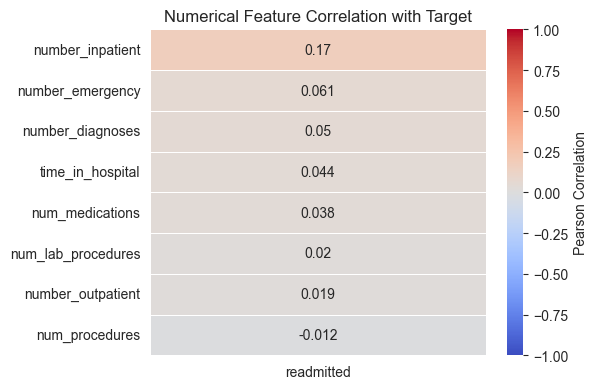

**Interpretation Guide**

- Positive values indicate that higher feature values tend to be associated with the positive target class.
- Negative values indicate an inverse relationship with the target.
- Correlations close to zero suggest weak linear association, though such features may still be useful in nonlinear or interaction-based models.

**Top Positive Correlations with Target**

,readmitted
number_inpatient,0.165
number_emergency,0.061
number_diagnoses,0.050


**Top Negative Correlations with Target**

,readmitted
num_procedures,-0.012


### Numerical Feature Correlation Analysis

**Correlation Matrix**

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.000,0.318,0.191,0.466,-0.009,-0.010,0.074,0.220
num_lab_procedures,0.318,1.000,0.058,0.268,-0.008,-0.002,0.039,0.153
num_procedures,0.191,0.058,1.000,0.386,-0.025,-0.038,-0.066,0.074
num_medications,0.466,0.268,0.386,1.000,0.045,0.013,0.064,0.262
number_outpatient,-0.009,-0.008,-0.025,0.045,1.000,0.091,0.107,0.094
number_emergency,-0.010,-0.002,-0.038,0.013,0.091,1.000,0.267,0.056
number_inpatient,0.074,0.039,-0.066,0.064,0.107,0.267,1.000,0.105
number_diagnoses,0.220,0.153,0.074,0.262,0.094,0.056,0.105,1.000


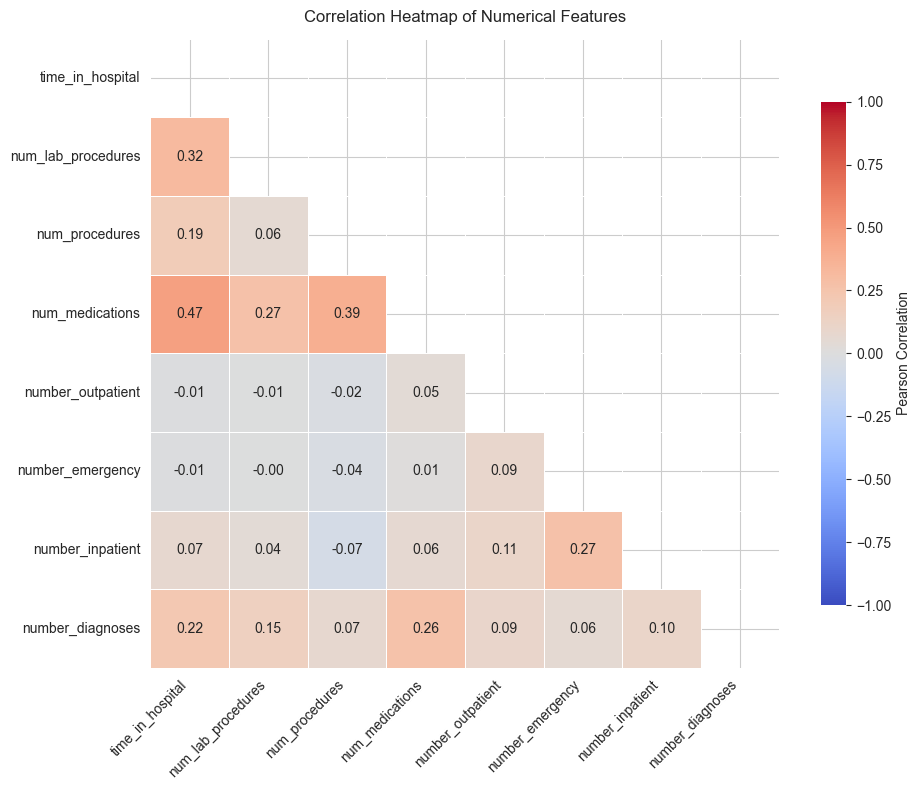

**Top 10 Strongest Pairwise Correlations**

,feature_1,feature_2,correlation,abs_correlation
0,time_in_hospital,num_medications,0.466,0.466
1,num_procedures,num_medications,0.386,0.386
2,time_in_hospital,num_lab_procedures,0.318,0.318
3,num_lab_procedures,num_medications,0.268,0.268
4,number_emergency,number_inpatient,0.267,0.267
5,num_medications,number_diagnoses,0.262,0.262
6,time_in_hospital,number_diagnoses,0.220,0.220
7,time_in_hospital,num_procedures,0.191,0.191
8,num_lab_procedures,number_diagnoses,0.153,0.153
9,number_outpatient,number_inpatient,0.107,0.107


### Interpretation Notes

- **Feature-to-feature correlation** helps identify potentially redundant variables and possible multicollinearity concerns, especially for linear models.
- **Feature-to-target correlation** is useful for screening direct linear signal, but it should not be treated as a final measure of feature importance.
- Tree-based models can still benefit from features with weak target correlation if those features contribute through nonlinear splits or interactions.
- If very strong pairwise correlations are found, consider whether both features should be retained, transformed, regularized, or reviewed for redundancy.

In [21]:
display_correlation_analysis(df_cleaned, numerical_columns, target)

The Pearson correlation heatmap and pairwise ranking table reveal a set of modest but interpretable inter-feature relationships among the eight numerical columns, with uniformly weak correlations against the binary target.

**Modeling implications.** The weak linear target correlations reinforce that this is a non-linear classification problem where interaction effects and ensemble methods (Random Forest, XGBoost) are expected to outperform linear baselines. For any linear model included in the comparison, the `time_in_hospital`–`num_medications` correlation (r = 0.466) and the broader encounter-intensity cluster should be assessed via VIF; log1p transformations of the zero-inflated prior utilisation variables will also help stabilise correlation estimates. No pair exceeds the 0.7–0.8 threshold typically associated with problematic multicollinearity, so no feature needs to be removed on correlation grounds alone.

**Target correlations are weak across the board.** The strongest individual correlations with `readmitted` are `number_inpatient` (r = 0.165), `number_emergency` (r = 0.061), and `number_diagnoses` (r = 0.050). All remaining features — `time_in_hospital`, `num_medications`, `num_lab_procedures`, `number_outpatient`, and `num_procedures` — produce target correlations below 0.05 in absolute value. This is consistent with the bivariate analysis, which showed that `number_inpatient` and `number_emergency` carried the largest mean-based separation. The low linear correlations for the other six features do not imply they are uninformative — Pearson correlation measures only linear association and is sensitive to the extreme zero-inflation and right skew present in these distributions. Tree-based models will likely extract non-linear signal that this metric cannot capture.

**Prior utilisation features are largely independent of the encounter-intensity cluster.** `number_inpatient` and `number_emergency` correlate most strongly with each other (r = 0.267), reflecting that patients with high emergency visit history also tend to have more inpatient admissions. Their correlations with the encounter-intensity features are all below 0.11, confirming that prior utilisation is capturing a distinct dimension of patient risk from what the current-encounter variables measure. This independence strengthens the case for retaining all three prior utilisation variables alongside the current-encounter features — they are not redundant with each other.

**The strongest feature–feature correlation is between `time_in_hospital` and `num_medications` (r = 0.466).** This is the only pair approaching moderate correlation in the dataset. Clinically, the relationship is intuitive: longer stays tend to accompany more complex pharmacotherapy. For linear models, this degree of correlation is worth monitoring — a VIF check at the modeling stage is warranted — but it is not high enough to mandate dropping either feature outright. For tree-based models, this collinearity is harmless.

**`num_medications` and `number_diagnoses` also correlate with each other (r = 0.262) and with `num_lab_procedures` (r = 0.268).** These pairings reinforce the encounter-intensity cluster and are all clinically coherent — more diagnoses imply more medications and more diagnostic workup. None of these pairwise values crosses 0.5, so multicollinearity remains a moderate rather than critical concern.

**A cluster of encounter-intensity correlations forms around `time_in_hospital`.** Beyond its correlation with `num_medications`, `time_in_hospital` also correlates moderately with `num_lab_procedures` (r = 0.318), `num_procedures` (r = 0.191), and `number_diagnoses` (r = 0.220). Together, these four features describe the complexity and resource intensity of the index encounter and move together to some degree — patients with longer stays tend to receive more procedures, more lab work, more medications, and carry more diagnoses. This cluster does not indicate redundancy severe enough to require feature removal, but it does suggest that any dimensionality reduction (e.g., PCA) applied to linear models could effectively compress these four into a single "encounter intensity" component without major information loss.

### EDA for Preprocessing

This section consolidates the completed EDA into concrete preprocessing decisions for modeling.

### Final Preprocessing Decisions

After completing the EDA analysis, two data-quality steps were identified as remaining preprocessing — corrections that must happen before any feature engineering or modeling, because they address structural integrity of the dataset rather than feature construction.

**1) Leakage filtering — remove structurally non-readmittable encounters**
- Exclude `discharge_disposition_id` codes `{11, 17, 19, 20, 27}` (expired, hospice, died). These encounters have a 0% readmission rate by definition — they cannot be readmitted within 30 days. Retaining them would inflate apparent model performance without learning clinically useful signal.
- This removed **1,671 records** (1.6% of the cleaned dataset), leaving **100,095 encounters**.

**2) Gender cleaning — remove Unknown/Invalid values**
- Drop the ~3 records (0.003%) with `gender` in `{'Unknown', 'Invalid'}`. These are too few to impute meaningfully and could create encoding artifacts.
- After the current leakage filter, **0 records** were removed (all invalid-gender records had already been captured by the leakage filter).

### Final Preprocessing

This section implements the pipeline decisions derived from EDA. Each step is wrapped in a helper function for clarity and reusability. The output is `df_preprocessed`, which will be the input to the feature engineering section.

In [22]:
df_preprocessed = filter_leakage_records(df_cleaned)
print("✓ df_preprocessed created from df_cleaned")

✓ Removed 1,671 records with structural-zero discharge codes {17, 19, 20, 27, 11}
  Discharge code breakdown: 1671 total
  Records remaining: 100,095
✓ df_preprocessed created from df_cleaned


In [23]:
df_preprocessed = clean_gender(df_preprocessed)
print("✓ df_preprocessed: gender cleaned")

✓ No Unknown/Invalid gender records found
  Records remaining: 100,095
✓ df_preprocessed: gender cleaned


In [24]:
filepath_preprocessed = "../data/processed/diabetic_data_preprocessed.csv"
df_preprocessed.to_csv(filepath_preprocessed, index=False)
print(f"✓ Preprocessed DataFrame saved to {filepath_preprocessed}")

print(f"\n✓ Final shape: {df_preprocessed.shape[0]:,} records × {df_preprocessed.shape[1]} features")

print("\n✓ New features vs. original clean data:")
original_cols = set(df_cleaned.columns)
new_cols = [c for c in df_preprocessed.columns if c not in original_cols]
print(f"  Added columns ({len(new_cols)}): {new_cols}")

print("\n✓ Target distribution after preprocessing:")
vc = df_preprocessed['readmitted'].value_counts()
print(f"  Negative (0): {vc.get(0, 0):,}  ({vc.get(0, 0)/len(df_preprocessed):.1%})")
print(f"  Positive (1): {vc.get(1, 0):,}  ({vc.get(1, 0)/len(df_preprocessed):.1%})")

print("\n✓ Sample of preprocessed data:")
display(df_preprocessed.head())

✓ Preprocessed DataFrame saved to ../data/processed/diabetic_data_preprocessed.csv

✓ Final shape: 100,095 records × 44 features

✓ New features vs. original clean data:
  Added columns (0): []

✓ Target distribution after preprocessing:
  Negative (0): 88,738  (88.7%)
  Positive (1): 11,357  (11.3%)

✓ Sample of preprocessed data:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,Unknown,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,11,5,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,Unknown,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,Unknown,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,0


## Feature Engineering

### Feature Engineering Plan

Building directly on `df_preprocessed`, this section converts every variable into numeric form, selects the most informative features, and prepares train-ready datasets. Preprocessing addressed data quality (leakage filtering and gender cleaning); feature engineering handles everything else.

---

**Step 1 — Diagnosis code grouping.**  
Map each of the three high-cardinality ICD-9 diagnosis columns (~750 unique codes) to 16 standard clinical chapters via a custom function, since no library encoder handles ICD-9 range-based grouping.

**Step 2 — Utilization features and administrative categorical recoding.**  
Helper functions from `src.feature_engineering` apply the transformations identified in EDA: `log1p` of utilization counts, binary flags, admission type consolidation, discharge disposition grouping, admission source grouping, and clinical flag encoding (`change`, `diabetesMed`, `insulin_adjusted`, test indicators).

**Step 3 — Age one-hot encoding.**  
The bivariate EDA showed a non-monotonic readmission gradient across age bands. One-hot encode with `pd.get_dummies` to let models assign independent weights per cohort instead of imposing a false ordinal ranking.

**Step 4 — Medication feature encoding.**  
Map each medication column's four string levels (`No`/`Steady`/`Down`/`Up`) to a 3-level ordinal (0/1/2) using `.replace()`. `Down` and `Up` collapse to the same level — the EDA showed both adjustment directions produce similar elevated readmission rates (~13-14%) vs. `No` (~10%) and `Steady` (~11%).

**Step 5 — Remaining categorical one-hot encoding.**  
One-hot encode all remaining string columns (discharge, admission source/type, race, gender, medical_specialty, lab test results, diagnosis chapters) via `pd.get_dummies`. `drop_first=False` to preserve all levels for fairness auditing.

**Step 6 — Train/test split.**  
Stratified 80/20 split with `RANDOM_STATE = 42`, before any resampling or feature selection.

**Step 7 — Numerical scaling.**  
`StandardScaler` fitted on the training set only, applied to both splits. Scaled versions are for linear/distance-based models; tree-based models use unscaled data.

**Step 8 — Feature selection.**  
Apply `mutual_info_classif` as the filter method — it captures non-linear dependencies and is scale-invariant, avoiding the limitations of chi-squared (which inflates scores for high-magnitude raw counts and requires non-negative inputs). Features with MI > 0 are retained. An embedded method (tree-based feature importance) will follow in the modeling notebook. This reduces noise, speeds up training, and can improve generalization — especially important given the ~170 post-OHE features.

**Step 9 — Dimensionality reduction (PCA).**  
Fit PCA on the scaled training set. Examine the cumulative variance explained curve, choose components retaining >=95% variance, and produce reduced datasets. Compare model performance on original vs. PCA-reduced features to evaluate the trade-off.

**Step 10 — Class imbalance handling (SMOTE).**  
SMOTE applied to training data only — after split, feature selection, and PCA. Produces balanced training sets for both the selected-feature and PCA-reduced versions. Test set is left untouched.

### Step 1: Diagnosis Code Grouping

In [25]:
df_features = df_preprocessed.copy()
print(f"✓ Starting feature engineering from df_preprocessed: {df_features.shape[0]:,} records × {df_features.shape[1]} columns")
print()

for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    chapter_col = f'{diag_col}_chapter'
    df_features[chapter_col] = df_features[diag_col].apply(map_icd9_to_chapter)
    df_features.drop(columns=[diag_col], inplace=True)
    print(f"✓ {diag_col} → {chapter_col} ({df_features[chapter_col].nunique()} unique chapters):")
    print(df_features[chapter_col].value_counts().to_string())
    print()

✓ Starting feature engineering from df_preprocessed: 100,095 records × 44 columns

✓ diag_1 → diag_1_chapter (19 unique chapters):
diag_1_chapter
circulatory        29781
endocrine          11357
respiratory        10057
digestive           9114
symptoms            7618
injury              6880
genitourinary       5015
musculoskeletal     4944
neoplasm            3299
infectious          2584
skin                2513
mental              2249
supplementary       1638
nervous_sensory     1192
blood               1095
pregnancy            687
congenital            50
other                 21
external               1

✓ diag_2 → diag_2_chapter (19 unique chapters):
diag_2_chapter
circulatory        30890
endocrine          20835
respiratory         9862
genitourinary       7845
symptoms            4542
digestive           3907
skin                3567
blood               2888
mental              2639
neoplasm            2452
injury              2390
infectious          1868
supplementary  

### Step 2: Utilization Features and Administrative Recoding

In [26]:
df_features = add_utilization_features(df_features)

✓ Binary utilization flags added: ['had_outpatient', 'had_emergency', 'had_inpatient', 'had_procedures']
✓ Log1p transforms added: ['log_outpatient', 'log_emergency', 'log_inpatient']


In [27]:
df_features = recode_admission_type(df_features)
print("✓ df_features: admission_type_id recoded")

✓ Consolidated 10,226 records (10.22%) with admission codes {5,6,8} → 'Unknown'
  Admission type value counts:
admission_type_id
1          52877
3          18739
2          18225
Unknown    10226
7             18
4             10
✓ df_features: admission_type_id recoded


In [28]:
df_features = group_discharge_disposition(df_features)

✓ discharge_disposition_id grouped into clinical categories:
discharge_disposition_id
home         73244
facility     21731
other         5096
inpatient       24


In [29]:
df_features = group_admission_source(df_features)

✓ admission_source_id grouped into clinical categories:
admission_source_id
emergency_room    56361
referral          30403
other              6935
transfer           6396


In [30]:
df_features = encode_clinical_flags(df_features)

✓ Binary indicator flags added: specialty_known, insulin_adjusted, glucose_tested, A1C_tested
✓ Recoded: change (Ch→1 / No→0), diabetesMed (Yes→1 / No→0)


### Step 3: Age Encoding

In [31]:
# One-hot encode age bands (non-monotonic readmission gradient — ordinal would misrepresent)
age_dummies = pd.get_dummies(df_features['age'], prefix='age', dtype=int)
df_features = pd.concat([df_features.drop(columns=['age']), age_dummies], axis=1)
print(f"✓ age one-hot encoded into {age_dummies.shape[1]} binary columns: {list(age_dummies.columns)}")

✓ age one-hot encoded into 10 binary columns: ['age_[0-10)', 'age_[10-20)', 'age_[20-30)', 'age_[30-40)', 'age_[40-50)', 'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)', 'age_[90-100)']


### Step 4: Medication Feature Encoding

In [32]:
# Ordinal-encode medications: No->0, Steady->1, Down/Up->2
# Collapsing Down/Up is supported by EDA: both directions show ~13-14% readmission
# vs No (~10%) and Steady (~11%) — direction matters less than the fact of adjustment.
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 2}
med_cols = [c for c in medication_features_group if c in df_features.columns]
if 'insulin' in df_features.columns:
    med_cols.append('insulin')

df_features[med_cols] = df_features[med_cols].replace(med_map).astype(int)
print(f"✓ Medication features encoded (No→0 / Steady→1 / Down|Up→2): {len(med_cols)} columns")
print(f"  {med_cols}")

✓ Medication features encoded (No→0 / Steady→1 / Down|Up→2): 21 columns
  ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'insulin']


### Step 5: Remaining Categorical Encoding

In [33]:
# One-hot encode all remaining string/categorical columns dynamically
# drop_first=False to preserve all levels for fairness auditing (race, gender)
df_features['admission_type_id'] = df_features['admission_type_id'].astype(str)

cat_cols = df_features.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'readmitted']  # exclude target
print(f"\u2713 Detected {len(cat_cols)} remaining categorical columns: {cat_cols}")

df_features = pd.get_dummies(df_features, columns=cat_cols, dtype=int, drop_first=False)
print(f"\u2713 One-hot encoded {len(cat_cols)} categorical columns")
print(f"  Final shape: {df_features.shape[0]:,} records \u00d7 {df_features.shape[1]} columns")

✓ Detected 11 remaining categorical columns: ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'diag_1_chapter', 'diag_2_chapter', 'diag_3_chapter']
✓ One-hot encoded 11 categorical columns
  Final shape: 100,095 records × 171 columns


### Step 6: Train/Test Split

In [34]:
X = df_features.drop(columns=['readmitted'])
y = df_features['readmitted'].astype(int)  # ensure int dtype for SMOTE compatibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"✓ Stratified 80/20 train/test split (RANDOM_STATE={RANDOM_STATE}):")
print(f"  Training set : {X_train.shape[0]:,} records × {X_train.shape[1]} features")
print(f"  Test set     : {X_test.shape[0]:,} records × {X_test.shape[1]} features")

print(f"\n✓ Target distribution — training set:")
vc_train = y_train.value_counts()
print(f"  Negative (0): {vc_train.get(0, 0):,}  ({vc_train.get(0, 0) / len(y_train):.1%})")
print(f"  Positive (1): {vc_train.get(1, 0):,}  ({vc_train.get(1, 0) / len(y_train):.1%})")

print(f"\n✓ Target distribution — test set:")
vc_test = y_test.value_counts()
print(f"  Negative (0): {vc_test.get(0, 0):,}  ({vc_test.get(0, 0) / len(y_test):.1%})")
print(f"  Positive (1): {vc_test.get(1, 0):,}  ({vc_test.get(1, 0) / len(y_test):.1%})")

✓ Stratified 80/20 train/test split (RANDOM_STATE=42):
  Training set : 80,076 records × 170 features
  Test set     : 20,019 records × 170 features

✓ Target distribution — training set:
  Negative (0): 70,990  (88.7%)
  Positive (1): 9,086  (11.3%)

✓ Target distribution — test set:
  Negative (0): 17,748  (88.7%)
  Positive (1): 2,271  (11.3%)


### Step 7: Numerical Scaling

In [35]:
# Dynamically detect continuous numerical features to scale.
# After encoding, binary flags (0/1) and ordinal medication columns (0/1/2)
# have at most 3 unique values — exclude them. Continuous features have many more.
numerical_feature_cols = [
    c for c in X_train.columns
    if X_train[c].dtype in ['int64', 'float64'] and X_train[c].nunique() > 3
]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numerical_feature_cols] = scaler.fit_transform(X_train[numerical_feature_cols])
X_test_scaled[numerical_feature_cols]  = scaler.transform(X_test[numerical_feature_cols])

print(f"\u2713 StandardScaler fitted on training set, applied to both splits")
print(f"  Scaled {len(numerical_feature_cols)} numerical columns: {numerical_feature_cols}")
print(f"\n  Unscaled versions (for tree-based models) : X_train  ({X_train.shape}), X_test  ({X_test.shape})")
print(f"  Scaled versions   (for linear models)    : X_train_scaled ({X_train_scaled.shape}), X_test_scaled ({X_test_scaled.shape})")

✓ StandardScaler fitted on training set, applied to both splits
  Scaled 11 numerical columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'log_outpatient', 'log_emergency', 'log_inpatient']

  Unscaled versions (for tree-based models) : X_train  ((80076, 170)), X_test  ((20019, 170))
  Scaled versions   (for linear models)    : X_train_scaled ((80076, 170)), X_test_scaled ((20019, 170))


### Step 8: Feature Selection

✓ Mutual information scores computed for 170 features

Top 20 features by MI score:
                           feature  mi_score
                max_glu_serum_none  0.019494
     discharge_disposition_id_home  0.016178
                       diabetesMed  0.014406
                     log_inpatient  0.011837
                    had_procedures  0.011683
                    race_Caucasian  0.011660
admission_source_id_emergency_room  0.011396
                  number_inpatient  0.011299
                     had_inpatient  0.011090
                   specialty_known  0.011049
               admission_type_id_1  0.010954
                    A1Cresult_none  0.010465
                     gender_Female  0.010349
         medical_specialty_Unknown  0.008229
                       gender_Male  0.008207
                            change  0.007501
                  number_diagnoses  0.005950
 discharge_disposition_id_facility  0.004739
                           insulin  0.004653
        diag_3_c

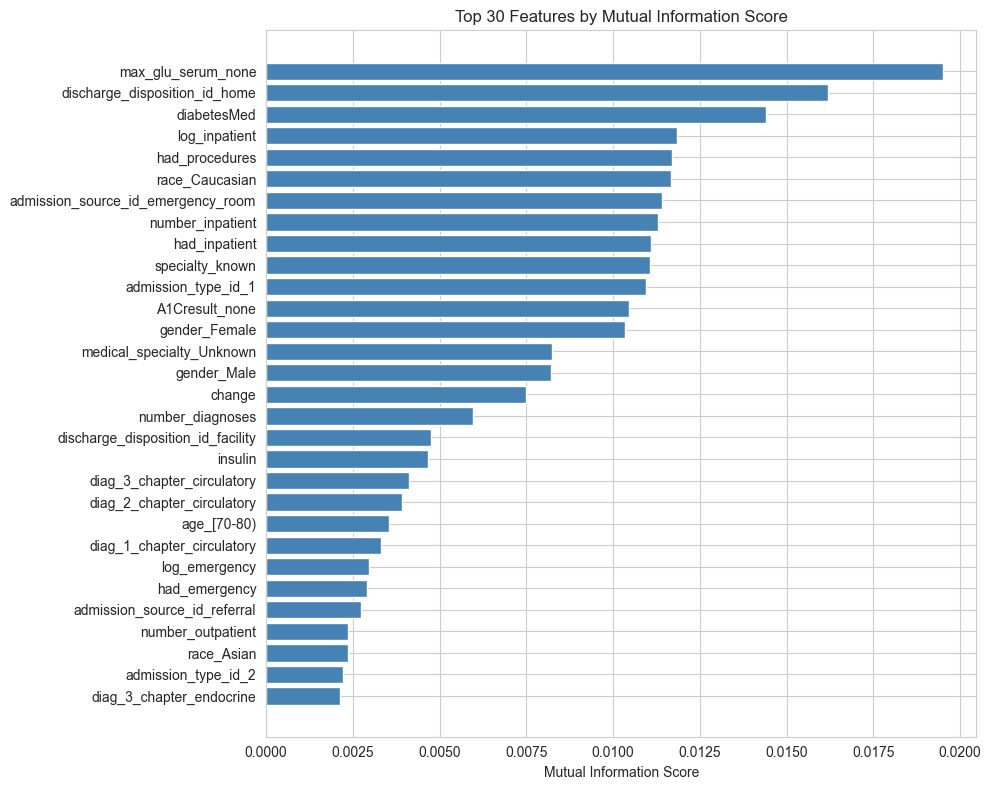

In [36]:
# --- Feature Selection ---
# Filter method: Mutual Information (captures non-linear dependencies, scale-invariant)
from sklearn.feature_selection import mutual_info_classif

# Compute mutual information scores — random_state ensures reproducibility
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)

# Examine feature scores
feature_scores = pd.DataFrame({
    'feature': X_train.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print(f"✓ Mutual information scores computed for {len(feature_scores)} features")
print(f"\nTop 20 features by MI score:")
print(feature_scores.head(20).to_string(index=False))

# Select features with MI > 0 (non-zero information about the target)
significant_features = feature_scores[feature_scores['mi_score'] > 0]['feature'].tolist()
print(f"\n✓ {len(significant_features)} features with MI > 0 (out of {len(feature_scores)})")

# Apply selection — keep informative features
X_train_selected = X_train[significant_features]
X_test_selected = X_test[significant_features]
X_train_scaled_selected = X_train_scaled[significant_features]
X_test_scaled_selected = X_test_scaled[significant_features]

print(f"\n✓ Feature matrix reduced: {X_train.shape[1]} → {X_train_selected.shape[1]} features")

# Visualize top 30 feature scores
fig, ax = plt.subplots(figsize=(10, 8))
top_30 = feature_scores.head(30)
ax.barh(range(len(top_30)), top_30['mi_score'].values, color='steelblue')
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 30 Features by Mutual Information Score')
plt.tight_layout()
plt.show()


### Step 9: Dimensionality Reduction (PCA)

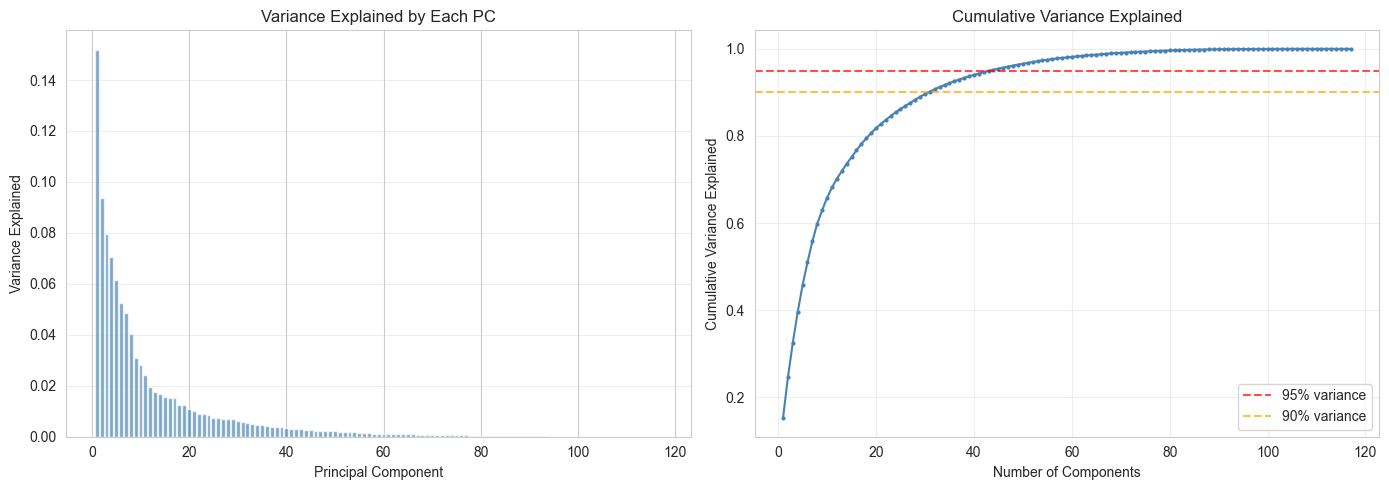

✓ Components for 95% variance: 44 (out of 117)
  Dimensionality reduction: 117 → 44 (62.4% reduction)

✓ PCA applied:
  Training set: (80076, 117) → (80076, 44)
  Test set:     (20019, 117) → (20019, 44)
  Variance retained: 95.21%


In [37]:
# --- PCA: Dimensionality Reduction ---
# PCA requires scaled data. Fit on training set only.

# Step 1: Fit PCA with all components to examine variance explained
pca_full = PCA()
pca_full.fit(X_train_scaled_selected)

variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

# Step 2: Visualize cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(variance_ratio) + 1), variance_ratio, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Variance Explained by Each PC')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='steelblue', markersize=2)
axes[1].axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Step 3: Choose components retaining >= 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"✓ Components for 95% variance: {n_components_95} (out of {X_train_scaled_selected.shape[1]})")
print(f"  Dimensionality reduction: {X_train_scaled_selected.shape[1]} → {n_components_95} ({(1 - n_components_95 / X_train_scaled_selected.shape[1]) * 100:.1f}% reduction)")

# Step 4: Apply PCA transformation
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled_selected)
X_test_pca = pca.transform(X_test_scaled_selected)

print(f"\n✓ PCA applied:")
print(f"  Training set: {X_train_scaled_selected.shape} → {X_train_pca.shape}")
print(f"  Test set:     {X_test_scaled_selected.shape} → {X_test_pca.shape}")
print(f"  Variance retained: {pca.explained_variance_ratio_.sum():.2%}")

#### PCA Component Interpretation

Although PCA components are linear combinations of the original 117 features, they can still be interpreted by examining their **loadings** — the weight each original feature carries in a given component. A high absolute loading means that feature strongly influences the component's direction.

Below we identify the top contributing original features for each of the leading principal components. This transparency allows the PCA-reduced model to remain clinically interpretable: instead of opaque "PC1, PC2, …" labels, each component can be described in terms of the original clinical variables that drive it.

✓ PCA Loadings: 44 components × 117 original features

Top 5 features by absolute loading for the first 10 components:


PC1 — 15.19% variance explained
--------------------------------------------------
  + number_inpatient                              +0.5057
  + log_inpatient                                 +0.5056
  + log_emergency                                 +0.4316
  + number_emergency                              +0.3987
  + had_inpatient                                 +0.2001

PC2 — 9.39% variance explained
--------------------------------------------------
  + time_in_hospital                              +0.5660
  + num_lab_procedures                            +0.4730
  + number_diagnoses                              +0.3825
  + num_procedures                                +0.3295
  − number_emergency                              -0.2351

PC3 — 7.95% variance explained
--------------------------------------------------
  + number_emergency                              

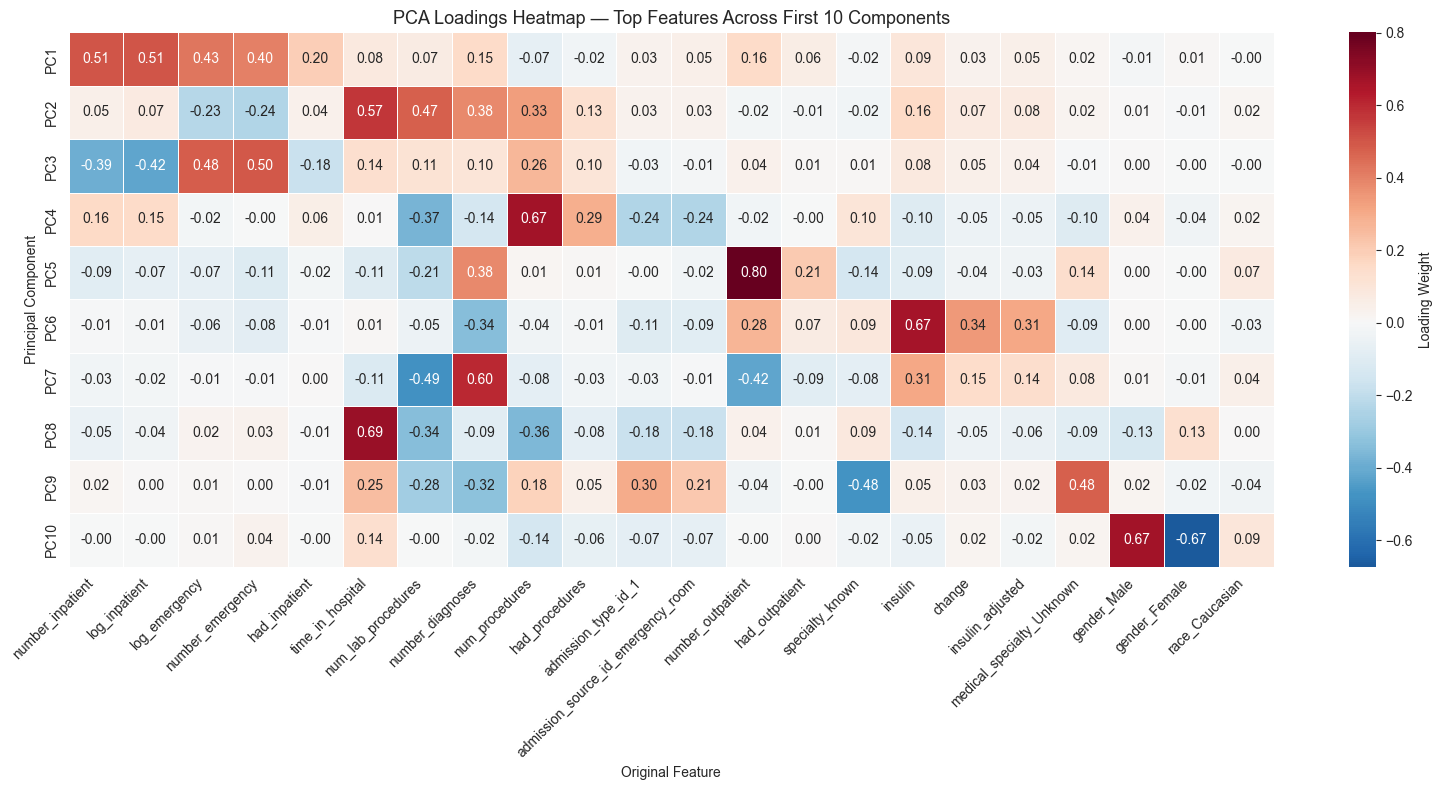


✓ PCA interpretation complete — each component can be traced back to original clinical features


In [38]:
# --- PCA Component Interpretation ---
# Build a loadings DataFrame: rows = components, columns = original feature names
feature_names = X_train_scaled_selected.columns.tolist()
loadings = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Show top contributing features per component (top N by absolute loading)
n_top = 5
n_components_to_show = min(10, pca.n_components_)

print(f"✓ PCA Loadings: {pca.n_components_} components × {len(feature_names)} original features\n")
print(f"Top {n_top} features by absolute loading for the first {n_components_to_show} components:\n")
print("=" * 80)

pca_interpretation = {}
for i in range(n_components_to_show):
    pc = f"PC{i+1}"
    var_pct = pca.explained_variance_ratio_[i] * 100
    top_features = loadings.iloc[i].abs().nlargest(n_top)
    signed_values = loadings.iloc[i][top_features.index]

    print(f"\n{pc} — {var_pct:.2f}% variance explained")
    print("-" * 50)
    for feat, weight in signed_values.items():
        direction = "+" if weight > 0 else "−"
        print(f"  {direction} {feat:<45s} {weight:+.4f}")
    pca_interpretation[pc] = list(top_features.index)

print("\n" + "=" * 80)

# --- Heatmap of top loadings across leading components ---
# Collect unique top features across the first N components for the heatmap
top_features_set = []
for feats in pca_interpretation.values():
    for f in feats:
        if f not in top_features_set:
            top_features_set.append(f)

heatmap_data = loadings.iloc[:n_components_to_show][top_features_set]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    heatmap_data, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    linewidths=0.5, ax=ax, cbar_kws={"label": "Loading Weight"}
)
ax.set_title(f"PCA Loadings Heatmap — Top Features Across First {n_components_to_show} Components", fontsize=13)
ax.set_xlabel("Original Feature")
ax.set_ylabel("Principal Component")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n✓ PCA interpretation complete — each component can be traced back to original clinical features")

#### PCA Component Summary — Clinical Interpretation

The loadings heatmap above reveals that each principal component captures a distinct clinical theme. Below is a concise interpretation of the first 10 components (which collectively explain the majority of variance):

| Component | Variance | Clinical Label | Key Drivers |
|-----------|----------|---------------|-------------|
| **PC1** | Highest | **Prior Healthcare Utilization** | `number_inpatient` (+0.51), `log_inpatient` (+0.51), `log_emergency` (+0.43), `number_emergency` (+0.40) — patients with frequent prior admissions and ER visits |
| **PC2** | — | **Current Encounter Complexity** | `time_in_hospital` (+0.57), `num_lab_procedures` (+0.47), `number_diagnoses` (+0.38), `num_procedures` (+0.33) — longer stays with more tests and diagnoses |
| **PC3** | — | **Emergency vs. Inpatient Contrast** | `number_emergency` (+0.50), `log_emergency` (+0.48) vs. `log_inpatient` (−0.42), `number_inpatient` (−0.39) — separates ER-heavy from inpatient-heavy utilization patterns |
| **PC4** | — | **Procedural Intensity** | `num_procedures` (+0.67), `had_procedures` (+0.29) vs. `num_lab_procedures` (−0.37) — patients receiving surgical/procedural interventions rather than lab workups |
| **PC5** | — | **Outpatient Utilization** | `number_outpatient` (+0.80), `had_outpatient` (+0.21) — dominated almost entirely by outpatient visit history |
| **PC6** | — | **Insulin Management** | `insulin` (+0.67), `change` (+0.34), `insulin_adjusted` (+0.31) — captures medication-change behavior, particularly insulin titration |
| **PC7** | — | **Diagnostic Burden vs. Lab/Outpatient Workup** | `number_diagnoses` (+0.60), `num_lab_procedures` (−0.49), `number_outpatient` (−0.42) — separates high-comorbidity patients from those with heavy lab or outpatient activity |
| **PC8** | — | **Extended Observation Stays** | `time_in_hospital` (+0.69) vs. `num_procedures` (−0.36), `num_lab_procedures` (−0.34) — long stays *without* proportional procedural or lab activity (monitoring/observation pattern) |
| **PC9** | — | **Unknown Specialty / Emergency Pathway** | `medical_specialty_Unknown` (+0.48), `specialty_known` (−0.48), `admission_source_id_emergency_room` (+0.30) — identifies admissions through the ER where the treating specialty was not recorded |
| **PC10** | — | **Gender** | `gender_Male` (+0.67), `gender_Female` (−0.67) — purely a demographic gender axis |

**Key Takeaway:** The PCA components are *not* opaque mathematical abstractions — they map onto clinically meaningful dimensions: prior utilization history (PC1, PC3, PC5), current encounter severity (PC2, PC4, PC8), treatment decisions (PC6), comorbidity burden (PC7), care pathway (PC9), and demographics (PC10). This interpretability supports using PCA-reduced features as a viable deployment track, since SHAP values on PCA components can be back-projected to original features for clinical explanation.

### Step 10: Class Imbalance — SMOTE

In [39]:
# SMOTE applied after split, feature selection, and PCA — training data only.
# Test set is left untouched for unbiased evaluation.

smote = SMOTE(random_state=RANDOM_STATE)

# Resample the selected-feature versions
X_train_selected_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train.values)
X_train_scaled_selected_resampled, _ = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_scaled_selected, y_train.values)

# Resample the PCA-reduced version
X_train_pca_resampled, _ = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_pca, y_train.values)

vc_res = pd.Series(y_train_resampled).value_counts()
print(f"✓ SMOTE resampling complete (training data only):")
print(f"  Negative (0): {vc_res.get(0, 0):,}")
print(f"  Positive (1): {vc_res.get(1, 0):,}")
print(f"  Balanced training size: {len(y_train_resampled):,}")
print(f"\n  Datasets produced:")
print(f"  X_train_selected_resampled        : {X_train_selected_resampled.shape}")
print(f"  X_train_scaled_selected_resampled  : {X_train_scaled_selected_resampled.shape}")
print(f"  X_train_pca_resampled              : {X_train_pca_resampled.shape}")

✓ SMOTE resampling complete (training data only):
  Negative (0): 70,990
  Positive (1): 70,990
  Balanced training size: 141,980

  Datasets produced:
  X_train_selected_resampled        : (141980, 117)
  X_train_scaled_selected_resampled  : (141980, 117)
  X_train_pca_resampled              : (141980, 44)


In [40]:
processed_dir = "../data/processed"

# Original splits
X_train.to_csv(f"{processed_dir}/X_train.csv", index=False)
X_test.to_csv(f"{processed_dir}/X_test.csv", index=False)
y_train.to_csv(f"{processed_dir}/y_train.csv", index=False)
y_test.to_csv(f"{processed_dir}/y_test.csv", index=False)

# Scaled splits
X_train_scaled.to_csv(f"{processed_dir}/X_train_scaled.csv", index=False)
X_test_scaled.to_csv(f"{processed_dir}/X_test_scaled.csv", index=False)

# Feature-selected splits
X_train_selected.to_csv(f"{processed_dir}/X_train_selected.csv", index=False)
X_test_selected.to_csv(f"{processed_dir}/X_test_selected.csv", index=False)
X_train_scaled_selected.to_csv(f"{processed_dir}/X_train_scaled_selected.csv", index=False)
X_test_scaled_selected.to_csv(f"{processed_dir}/X_test_scaled_selected.csv", index=False)

# PCA-reduced splits
pd.DataFrame(X_train_pca).to_csv(f"{processed_dir}/X_train_pca.csv", index=False)
pd.DataFrame(X_test_pca).to_csv(f"{processed_dir}/X_test_pca.csv", index=False)

# SMOTE-resampled training sets
pd.DataFrame(X_train_selected_resampled, columns=X_train_selected.columns).to_csv(
    f"{processed_dir}/X_train_selected_resampled.csv", index=False)
pd.DataFrame(X_train_scaled_selected_resampled, columns=X_train_scaled_selected.columns).to_csv(
    f"{processed_dir}/X_train_scaled_selected_resampled.csv", index=False)
pd.DataFrame(X_train_pca_resampled).to_csv(
    f"{processed_dir}/X_train_pca_resampled.csv", index=False)
pd.Series(y_train_resampled, name='readmitted').to_csv(
    f"{processed_dir}/y_train_resampled.csv", index=False)

# ── Save fitted preprocessing objects (needed for PCA deployment pipeline) ────
import joblib
import json as _json

# PCA transformer (fitted on scaled training data)
joblib.dump(pca, f"{processed_dir}/pca_transformer.joblib")

# StandardScaler (fitted on training data)
joblib.dump({
    "scaler": scaler,
    "continuous_cols": numerical_feature_cols,
}, f"{processed_dir}/standard_scaler.joblib")

# MI-selected feature names (117 features)
with open(f"{processed_dir}/selected_features.json", "w") as f:
    _json.dump(significant_features, f, indent=2)

print("✓ All feature-engineered data saved to data/processed/:")
import os
for fname in sorted(os.listdir(processed_dir)):
    if fname.endswith('.csv'):
        size = os.path.getsize(f"{processed_dir}/{fname}") // 1024
        print(f"  {fname}  ({size:,} KB)")

print(f"\n✓ Fitted preprocessing objects saved:")
print(f"  pca_transformer.joblib     — PCA ({pca.n_components_} components)")
print(f"  standard_scaler.joblib     — StandardScaler ({len(numerical_feature_cols)} continuous features)")
print(f"  selected_features.json     — MI-selected feature names ({len(significant_features)} features)")

print(f"\n✓ Feature engineering complete.")
print(f"  Ready for modeling:")
print(f"  Selected features (unscaled) : X_train_selected / X_test_selected")
print(f"  Selected features (scaled)   : X_train_scaled_selected / X_test_scaled_selected")
print(f"  PCA-reduced (scaled)         : X_train_pca / X_test_pca")
print(f"  SMOTE balanced               : *_resampled variants + y_train_resampled")

✓ All feature-engineered data saved to data/processed/:
  X_test.csv  (6,980 KB)
  X_test_pca.csv  (17,256 KB)
  X_test_scaled.csv  (10,509 KB)
  X_test_scaled_selected.csv  (7,724 KB)
  X_test_selected.csv  (4,803 KB)
  X_train.csv  (27,918 KB)
  X_train_pca.csv  (69,025 KB)
  X_train_pca_resampled.csv  (122,497 KB)
  X_train_resampled.csv  (49,931 KB)
  X_train_scaled.csv  (42,021 KB)
  X_train_scaled_resampled.csv  (74,464 KB)
  X_train_scaled_selected.csv  (30,888 KB)
  X_train_scaled_selected_resampled.csv  (54,732 KB)
  X_train_selected.csv  (19,216 KB)
  X_train_selected_resampled.csv  (34,366 KB)
  diabetic_data_cleaned.csv  (15,982 KB)
  diabetic_data_preprocessed.csv  (15,578 KB)
  y_test.csv  (39 KB)
  y_train.csv  (156 KB)
  y_train_resampled.csv  (277 KB)
  y_train_scaled_resampled.csv  (277 KB)

✓ Fitted preprocessing objects saved:
  pca_transformer.joblib     — PCA (44 components)
  standard_scaler.joblib     — StandardScaler (11 continuous features)
  selected_features

## Feature Engineering Summary

The feature engineering pipeline transformed 100,095 preprocessed diabetic encounter records into several ready-to-model datasets, advancing the feature matrix from 44 raw columns through domain-specific transformations, full encoding, a leakage-safe train/test split, and a progressive refinement trail ending with balanced, dimensionality-reduced training sets.

---

### Step 1 — Diagnosis Code Grouping

The three high-cardinality ICD-9 diagnosis columns (`diag_1`, `diag_2`, `diag_3`) were collapsed into 19 standardized clinical chapters via a custom range-based mapping — the only step that genuinely required a bespoke function, since no off-the-shelf encoder handles ICD-9 code ranges. The primary diagnosis (`diag_1`) is dominated by circulatory conditions (29,781 records, 29.8%), with endocrine disease second (11,357, 11.3%) — a count that exactly mirrors the total number of positive readmissions, consistent with uncontrolled diabetes being a principal readmission driver in this cohort. The secondary diagnosis (`diag_2`) shows a heavier endocrine contribution (20,835), reinforcing that co-managed metabolic comorbidities are pervasive. Grouping reduces three columns of 750-plus distinct ICD-9 codes to a tractable 19-level clinical representation that carries interpretable signal without inflating the feature space.

---

### Step 2 — Utilization Features and Administrative Recoding

Five helper functions applied the transformations identified during EDA:

- **Utilization features**: Four binary presence flags (`had_outpatient`, `had_emergency`, `had_inpatient`, `had_procedures`) capture whether prior service use occurred at all, sidestepping right-skewed count distributions. Three `log1p`-transformed counts (`log_outpatient`, `log_emergency`, `log_inpatient`) provide a compressed, approximately symmetric continuous representation for models sensitive to scale.
- **Admission type recoding**: 10,226 records (10.22%) with codes `{5, 6, 8}` — trauma centers, delivery, and undetermined — were consolidated into an `Unknown` category. These rare, clinically distinct pathways would otherwise produce sparse, unreliable indicator columns after one-hot encoding.
- **Discharge disposition grouping**: Simplified to four clinically meaningful categories — `home` (73,244, 73.2%), `facility` (21,731, 21.7%), `other` (5,096), and `inpatient` (24). The home-versus-facility split is expected to carry substantial readmission signal; discharge to a facility indicates higher acuity than a straightforward home discharge.
- **Admission source grouping**: Consolidated to four pathways — `emergency_room` (56,361, 56.3%), `referral` (30,403, 30.4%), `other` (6,935), and `transfer` (6,396). The ER-dominant profile reflects a high-acuity hospitalization pattern correlated with elevated readmission risk.
- **Clinical flags**: Four binary indicators were added — `specialty_known`, `insulin_adjusted`, `glucose_tested`, and `A1C_tested` — converting informative missingness into explicit predictive features. `change` and `diabetesMed` were recoded from string labels to binary integers (0/1).

---

### Step 3 — Age Encoding

Age was one-hot encoded into 10 decade-band columns (`age_[0-10)` through `age_[90-100)`) using `pd.get_dummies`. The bivariate EDA revealed a non-monotonic readmission gradient across age groups, with middle-aged cohorts behaving differently from the youngest and oldest bands. Ordinal encoding would have imposed a false linear ordering on what is effectively a non-linear, cohort-specific effect. One-hot encoding allows each band to carry an independent weight in any model that follows.

---

### Step 4 — Medication Feature Encoding

Twenty-one medication columns were ordinally mapped to three levels — `No → 0`, `Steady → 1`, `Down/Up → 2` — using `.replace()`. Collapsing `Down` and `Up` into a single adjusted level is supported by the EDA: both dosage-change directions showed nearly identical elevated readmission rates (~13–14%) compared to `No` (~10%) and `Steady` (~11%). The clinically meaningful distinction is whether a medication was altered at all, not the direction of change; maintaining four levels would ask the model to distinguish a signal the data does not support.

---

### Step 5 — Remaining Categorical Encoding

Eleven remaining string columns — discharge disposition, admission source and type, race, gender, medical specialty, lab test results (`max_glu_serum`, `A1Cresult`), and the three ICD-9 chapter columns — were one-hot encoded with `pd.get_dummies`. `drop_first=False` was a deliberate choice: dropping a reference category for `race` and `gender` would suppress demographic subgroups needed for the planned fairness audit. Following all encoding steps, the feature matrix reached its maximum width: **100,095 records × 171 columns**.

---

### Step 6 — Train/Test Split

A stratified 80/20 split produced:
- **Training set**: 80,076 records × 170 features (88.7% negative / 11.3% positive)
- **Test set**: 20,019 records × 170 features (88.7% negative / 11.3% positive)

Stratification preserved the 88.7/11.3 class ratio across both partitions. The split precedes all subsequent transformations — feature selection, scaling, PCA, and SMOTE — ensuring the test set is never seen during any fitting step.

---

### Step 7 — Numerical Scaling

`StandardScaler` was fitted exclusively on the training set and applied to both splits, standardizing 11 continuous features: the eight original utilization and clinical count columns plus the three `log1p`-transformed variants. Two parallel feature matrices were maintained:
- **Unscaled** (`X_train`, `X_test`): for tree-based models (Random Forest, XGBoost), which are invariant to linear feature rescaling.
- **Scaled** (`X_train_scaled`, `X_test_scaled`): for linear models (Logistic Regression) and as the input for PCA, which assumes standardized inputs.

Fitting the scaler on training data only is required; applying test-derived statistics for normalization would constitute data leakage.

---

### Step 8 — Feature Selection

Mutual information (`mutual_info_classif` with `random_state=42`) was applied to the unscaled training data to score all 170 features. Unlike chi-squared — which requires non-negative inputs and inflates scores for high-magnitude raw counts vs. binary indicators — mutual information is **scale-invariant** and captures **non-linear dependencies** between features and the target. Features with MI > 0 (non-zero information about the target) were retained, yielding **117 informative features** (a 31% reduction from 170).

The top features by mutual information score reveal a clinically coherent ranking:

| Feature | MI Score |
|---|---|
| `max_glu_serum_none` | 0.0195 |
| `discharge_disposition_id_home` | 0.0162 |
| `diabetesMed` | 0.0144 |
| `log_inpatient` | 0.0118 |
| `had_procedures` | 0.0117 |
| `race_Caucasian` | 0.0117 |
| `admission_source_id_emergency_room` | 0.0114 |
| `number_inpatient` | 0.0113 |

Unlike the chi-squared ranking — which was dominated by raw utilization counts inflated by magnitude — the MI ranking surfaces clinically interpretable signals: whether glucose was tested, discharge destination, diabetes medication status, and prior inpatient history all appear near the top, reflecting a more balanced view of predictive importance across both binary and continuous features.

The feature-selected matrices (`X_train_selected` / `X_test_selected`) form the primary input for both tree-based and linear model paths.

---

### Step 9 — Dimensionality Reduction (PCA) and Component Interpretation

PCA was fitted on the **scaled, feature-selected** training matrix (117 features). The cumulative variance curve shows **44 principal components accounting for 95.21% of total variance** — a 62.4% reduction (117 → 44 dimensions). The sharp initial rise in explained variance across the first 5–10 components, followed by a long gradual plateau, indicates a compact dominant signal manifold embedded in a sparser representation space. This is consistent with a feature set containing many correlated OHE-derived binary indicators whose variation largely reflects a small number of underlying clinical phenomena. PCA was fitted on the training set only; the test set was subsequently projected onto the training-derived components.

**Component Interpretation.** To preserve clinical interpretability for the PCA track, the loadings matrix (`pca.components_`) was examined for each of the leading components. Each principal component is a weighted linear combination of the original 117 features; by identifying the features with the highest absolute loadings, we can describe what each component captures in domain terms. The top 5 contributing features per component were extracted and visualized in a heatmap, enabling the PCA-reduced model to retain traceability to the original clinical variables — critical for downstream SHAP explainability and clinical communication of model predictions.

---

### Step 10 — Class Imbalance (SMOTE)

SMOTE was applied last — after the split, feature selection, and PCA — to the training partition only. The pre-resampling class distribution was 70,990 negative (88.7%) vs. 9,086 positive (11.3%), approximately an 8:1 imbalance. After oversampling, both classes reached 70,990 observations, producing a **balanced training set of 141,980 records**. Three parallel resampled training sets were produced to align with the three modeling tracks:
- `X_train_selected_resampled` (141,980 × 117): tree-based models
- `X_train_scaled_selected_resampled` (141,980 × 117): linear models
- `X_train_pca_resampled` (141,980 × 44): PCA-based pipeline

The test set was deliberately left class-imbalanced to ensure evaluation reflects real-world prevalence.

---

### Artifact Summary

All transformed datasets were persisted to `data/processed/`, providing six modeling-ready input configurations:

| Dataset Pair | Features | Training Records | Notes |
|---|---|---|---|
| `X_train` / `X_test` | 170 | 80,076 | Full matrix, unscaled |
| `X_train_scaled` / `X_test_scaled` | 170 | 80,076 | Full matrix, scaled |
| `X_train_selected` / `X_test_selected` | 117 | 80,076 | MI filtered, unscaled |
| `X_train_scaled_selected` / `X_test_scaled_selected` | 117 | 80,076 | MI filtered, scaled |
| `X_train_pca` / `X_test_pca` | 44 | 80,076 | PCA-reduced (95.21% variance) |
| `*_resampled` variants | 117 / 44 | 141,980 | SMOTE-balanced training only |

In addition, three fitted preprocessing objects were saved for use in the modeling and deployment pipeline:

| Artifact | Description |
|---|---|
| `pca_transformer.joblib` | Fitted PCA (44 components, 95.21% variance retained) |
| `standard_scaler.joblib` | Fitted StandardScaler + list of continuous columns |
| `selected_features.json` | MI-selected feature names (117 features) |

---

### Implications for Modeling

The pipeline produces three parallel training tracks designed to evaluate different model families under comparable conditions:

1. **Tree-based models** (Random Forest, XGBoost) will consume `X_train_selected_resampled` (unscaled, 117 features). These models are invariant to monotonic rescaling and can naturally exploit the sparse OHE structure without PCA compression.
2. **Linear models** (Logistic Regression) require `X_train_scaled_selected_resampled` (scaled, 117 features) so that regularization operates uniformly across features with different magnitudes.
3. **PCA track** (`X_train_pca_resampled`, 44 components) offers a reduced-dimensionality alternative. With component loadings mapped back to the original features, the PCA track retains clinical interpretability while potentially improving generalization through noise reduction — making it a viable deployment candidate alongside the full-feature tracks.

The primary evaluation metric is **AUC-ROC**, appropriate for the class imbalance context and the clinical cost asymmetry — a missed high-risk readmission carries greater operational cost than a false positive. Recall will serve as the primary secondary metric. Fairness sub-group analysis across `race` and `gender` — preserved through `drop_first=False` in Step 5 — is planned for the final evaluation stage.